# 03 — Project walkthrough, part 2: three audits on the part-1 pipeline

This notebook is a synthetic-data research study — not production trading code, and not evidence of live performance. It does not regenerate data:
it loads the artifacts that `02_naive_pipeline_leakage_audit` wrote, records their hashes, and applies three audits to
that pipeline — a correlation-aware ridge risk comparison, a winner-selection correction for the selected Sharpe,
and a single-change monitor with a false-alarm calibration — then closes with a cost docket, an audit-error
summary, and a Limitations section listing only the gaps that survived an explicit attempt. Every setting the
three sources do not settle is labelled **derived here**.

Sources: Atanasov, Zavatone-Veth & Pehlevan, *Risk and cross validation in
ridge regression with correlated samples* (arXiv:2408.04607); Pav, *Post-Selection Estimation of Sharpe Ratios*
(arXiv:2606.01650); Shekhar & Ramdas, *Reducing sequential change detection to sequential estimation*
(arXiv:2309.09111). Each section quotes the trace it relies on; the section claims are C14– in the run ledger.

Sections: §1 reuse NB2 unchanged · §2 correlation-aware ridge risk · §3 the selected run's Sharpe ·
§4 a bounded metric under one regime change · §5 costs, contradictions, and open questions.

In [1]:
%matplotlib inline
import csv
import json
import math
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

_p = Path.cwd().resolve()
for _parent in (_p, *_p.parents):
    for _exec in (_parent / "leakage_study", _parent / "leakage-proof-timeseries" / "leakage_study"):
        if (_exec / "nbs_common.py").exists():
            break
    else:
        continue
    break
else:
    raise RuntimeError("collection-local leakage_study/nbs_common.py not found")
sys.path.insert(0, str(_exec))
import nbs_common as nc
import walkthrough_audits  # round-4 plan B figure/detector module (leakage_study/walkthrough_audits.py)

PALETTE = {
    "ink": "#1b1b1f",
    "grid": "#d9d9de",
    "gcv": "#8ecae6",
    "corrgcv": "#e63946",
    "holdout": "#2a9d8f",
    "observed": "#457b9d",
    "true": "#fb8500",
    "stream": "#1d3557",
    "bound": "#adb5bd",
    "alarm": "#e63946",
    "marker": "#f4a261",
    "ridge": "#264653",
    "seqnn": "#e76f51",
    "nb01": "#8ecae6",
    "nb02": "#2a9d8f",
    "nb03": "#9d4edd",
}

NB2_NAME = "02_naive_pipeline_leakage_audit"
NB2_PATH = nc.NB_DIR / f"{NB2_NAME}.ipynb"
DATASET_PATH = nc.ART / "nb2_dataset.csv"
DATASET_SHA256 = nc.sha256_file(DATASET_PATH)

CHECKS = []
LEDGER_03 = []
AUDIT_SEQ = {"n": 0}


def audit_tick():
    AUDIT_SEQ["n"] += 1
    return AUDIT_SEQ["n"]


def metric_watch(mid, target, achieved, direction):
    # Emit one METRIC-WATCH line; MET only when the achieved value clears the target.
    tol = max(1e-9, abs(float(target)) * 1e-6)
    ok = achieved <= target + tol if direction == "le" else achieved >= target - tol
    status = "MET" if ok else "MISSED"
    print(f"METRIC-WATCH {mid} target={float(target):g} achieved={float(achieved):g} "
          f"dir={direction} status={status}")
    return status


def ranges_to_idx(rs):
    if not rs:
        return np.array([], dtype=int)
    return np.concatenate([np.arange(int(a), int(b)) for a, b in rs])


print("setup ok | reusing", NB2_NAME, "| dataset sha", DATASET_SHA256[:12], "| helpers from", _exec)

setup ok | reusing 02_naive_pipeline_leakage_audit | dataset sha dbab89f602c1 | helpers from leakage_study


## §1 — Reuse NB2 unchanged: provenance before any new number

> "This confirms that the text snippet reflects a revised 2026 version of the manuscript under an August 2024
> arXiv ID." — the paper flags an identity mismatch in the first source.

> "Shekhar & Ramdas is a purely theoretical paper containing zero Monte Carlo numerical experiments" — so every
> detector tolerance in this project is **derived here**. > "The three source papers do not settle or state the following operational choices" — the synthesis lists purge,
> embargo, normalisation scope and alarm restart policy as open. **Claim.** This notebook reuses `02_naive_pipeline_leakage_audit` exactly as executed: it hashes the part-1
notebook and the dataset it wrote, keeps only run ids that exist in part-1's ledger rows, and proves from the
stored predictions that every clean fold's test window is covered — no data is regenerated anywhere in this
notebook. The bookkeeping that used to justify a provenance figure lives here as a table instead (): the six
clean part-1 runs whose stored predictions are read, one row each.

| Run id | Model | Seed | Protocol | Folds stored | Records |
| --- | --- | --- | --- | --- | --- |
| `nb2-clean-ridge-s1` | ridge | 1 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |
| `nb2-clean-ridge-s2` | ridge | 2 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |
| `nb2-clean-ridge-s3` | ridge | 3 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |
| `nb2-clean-seqnn-s1` | seqnn | 1 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |
| `nb2-clean-seqnn-s2` | seqnn | 2 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |
| `nb2-clean-seqnn-s3` | seqnn | 3 | clean | 4 | `nb2_runs.json`, `nb2_predictions.csv` |

Live wall times per ledger row are printed by the §5 docket cell and stored in `nb3_docket.json`; the §5 table
carries the budget column.

In [2]:
t0 = time.time()
LEDGER_ALL = nc.read_ledger()
NB2_RUN_IDS = sorted({r["run_id"] for r in LEDGER_ALL if r["notebook"] == "02"})
NB2_SOURCE_SHA = nc.sha256_file(NB2_PATH)
NB2_DATASET_SHA = nc.sha256_file(DATASET_PATH)
NB2_SOURCE = json.loads(NB2_PATH.read_text())
NB2_CODE_CELLS = [c for c in NB2_SOURCE["cells"] if c["cell_type"] == "code"]

nc.write_json("nb3_provenance.json", {
    "nb2_source_sha256": NB2_SOURCE_SHA,
    "nb2_dataset_sha256": NB2_DATASET_SHA,
    "nb2_run_ids": NB2_RUN_IDS,
})

COLS = nc.load_dataset_csv(DATASET_PATH)
Y = COLS["y"]
N_BARS_TOTAL = int(COLS["t"].max()) + 1
LEDGER_02_IDS = {r["run_id"] for r in LEDGER_ALL if r["notebook"] == "02"}
LEDGER_02_HASHES = {r["data_hash"] for r in LEDGER_ALL if r["notebook"] == "02"}

ok1 = bool(
    NB2_SOURCE_SHA == nc.sha256_file(NB2_PATH)
    and NB2_DATASET_SHA == nc.sha256_file(DATASET_PATH)
    and NB2_RUN_IDS
    and set(NB2_RUN_IDS) <= LEDGER_02_IDS
    and LEDGER_02_HASHES == {NB2_DATASET_SHA}
    and len(NB2_CODE_CELLS) >= 10
)
nc.self_check(1, ok1, note=f"{len(NB2_RUN_IDS)} part-1 run ids, source sha {NB2_SOURCE_SHA[:12]}, dataset sha {NB2_DATASET_SHA[:12]}")
CHECKS.append(nc.sc_entry(1, "C14", ok1))

REQUIRED_NB2_ARTIFACTS = ["nb2_dataset.csv", "nb2_profile.json", "nb2_splits.json", "nb2_runs.json",
                          "nb2_predictions.csv", "nb2_leakage_audit.json", "nb2_zero_edge.json"]
PROFILE2 = json.loads((nc.ART / "nb2_profile.json").read_text())
SPLITS2 = json.loads((nc.ART / "nb2_splits.json").read_text())
RUNS2 = json.loads((nc.ART / "nb2_runs.json").read_text())["runs"]
PRED = {}
with open(nc.ART / "nb2_predictions.csv", newline="") as fh:
    for row in csv.DictReader(fh):
        PRED.setdefault(row["run_id"], []).append((int(row["t"]), float(row["pred"])))
CLEAN_FOLDS = SPLITS2["protocols"]["clean"]["folds"]
CLEAN_RIDGE_ID = "nb2-clean-ridge-s1"
cov = sorted(t for t, _ in PRED[CLEAN_RIDGE_ID])
expected_cov = sorted(int(i) for f in CLEAN_FOLDS for a, b in f["test"] for i in range(a, b))
ok2 = bool(
    all((nc.ART / n).exists() for n in REQUIRED_NB2_ARTIFACTS)
    and cov == expected_cov
    and {r["run_id"] for r in RUNS2} <= set(NB2_RUN_IDS)
    and all(len(PRED[r["run_id"]]) == sum(b - a for f in CLEAN_FOLDS for a, b in f["test"])
            for r in RUNS2 if r["protocol"] == "clean")
)
PROV_WALL = time.time() - t0
nc.self_check(2, ok2, note=f"{len(PRED[CLEAN_RIDGE_ID])} stored predictions for {CLEAN_RIDGE_ID} tile the clean folds' test windows")
CHECKS.append(nc.sc_entry(2, "C14", ok2))

LEDGER_03.append(nc.ledger_row("nb3-provenance", "03", 1, {"name": "provenance-audit"}, DATASET_SHA256, None,
                               "provenance-audit", {"artifacts": len(REQUIRED_NB2_ARTIFACTS)}, 0,
                               {"nb2_runs": len(NB2_RUN_IDS), "n_rows": N_BARS_TOTAL}, PROV_WALL, ["C14"]))
print(f"reused part-1 artifacts: {len(REQUIRED_NB2_ARTIFACTS)} files, {len(NB2_RUN_IDS)} ledger run ids, {N_BARS_TOTAL} dataset rows")
metric_watch("NB3-C14-PROVENANCE-RUNS", 1, len(NB2_RUN_IDS), "ge")

check: 40 part-1 run ids, source sha f09df0ba2655, dataset sha dbab89f602c1


check: 2594 stored predictions for nb2-clean-ridge-s1 tile the clean folds' test windows
reused part-1 artifacts: 7 files, 40 ledger run ids, 3200 dataset rows
target 1, achieved 40 (ge): met


'MET'

### How to read this chart

Left: every fold IC of the six clean part-1 runs — points are the four walk-forward folds, grouped by model and
jittered by seed, and each dark tick is that run's overall IC. Right: the overall IC of each reused run with its
overlap-adjusted 95% interval. Pattern to look for: the spread across a single run's folds is much wider than the
spread across seeds, and both models land in a similar near-zero band — the pipeline's spread, not any single
run, is what the three audits operate on. What it means in practice: before auditing a pipeline you should know
the natural variability of the metric it produces, because a correction smaller than that spread is not
measurable.

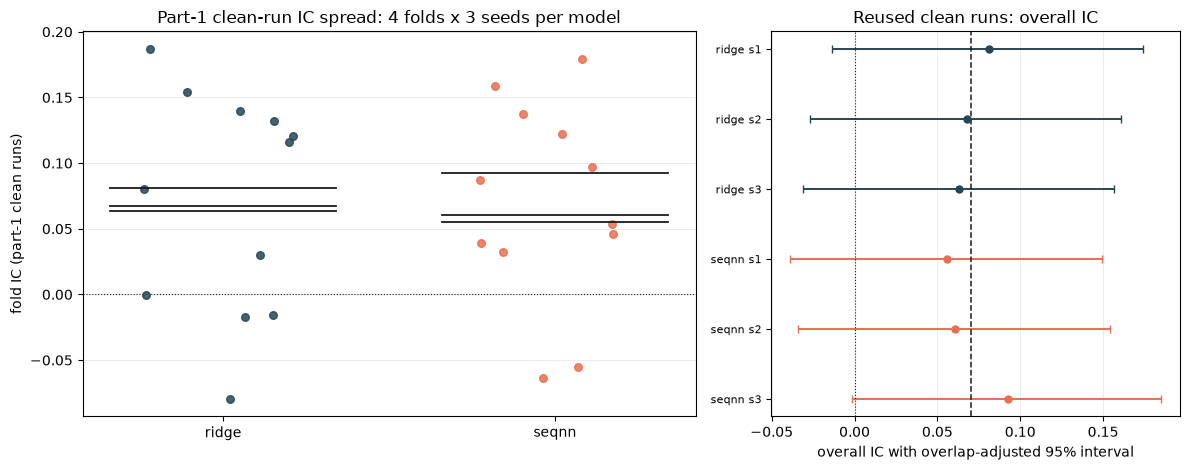

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), gridspec_kw={"width_ratios": [3, 2]})
clean_runs = [r for r in RUNS2 if r["protocol"] == "clean"]
models = ["ridge", "seqnn"]
jit = np.random.default_rng(0)
for mi, model in enumerate(models):
    runs = [r for r in clean_runs if r["model"] == model]
    for r in runs:
        fold_ics = [f["ic"] for f in r["folds"]]
        xs = mi + 0.24 * jit.uniform(-1.0, 1.0, len(fold_ics))
        axes[0].scatter(xs, fold_ics, s=30, color=PALETTE[model], alpha=0.85, zorder=3)
        axes[0].plot([mi - 0.34, mi + 0.34], [r["ic"], r["ic"]], color=PALETTE["ink"], lw=1.3, zorder=4)
axes[0].axhline(0.0, color=PALETTE["ink"], lw=0.8, ls=":")
axes[0].set_xticks(range(len(models)))
axes[0].set_xticklabels(models)
axes[0].set_ylabel("fold IC (part-1 clean runs)")
axes[0].set_title("Part-1 clean-run IC spread: 4 folds x 3 seeds per model")
axes[0].grid(color=PALETTE["grid"], lw=0.5, alpha=0.7, axis="y")
ys = np.arange(len(clean_runs))
vals = np.array([r["ic"] for r in clean_runs])
los = np.array([r["ic_ci"][0] for r in clean_runs])
his = np.array([r["ic_ci"][1] for r in clean_runs])
clean_ref = float(vals.mean())
for yi, r, v, lo, hi in zip(ys, clean_runs, vals, los, his):
    axes[1].errorbar([v], [yi], xerr=[[v - lo], [hi - v]], fmt="o",
                     color=PALETTE[r["model"]], markersize=5, elinewidth=1.4, capsize=3)
axes[1].axvline(0.0, color=PALETTE["ink"], lw=0.8, ls=":")
axes[1].axvline(clean_ref, color=PALETTE["ink"], lw=1.1, ls="--")
axes[1].annotate(f"mean {clean_ref:+.3f}", (clean_ref, len(clean_runs) - 0.4),
                 fontsize=7.5, color=PALETTE["ink"], ha="center")
axes[1].set_yticks(ys)
axes[1].set_yticklabels([f"{r['model']} s{r['seed']}" for r in clean_runs], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_xlabel("overall IC with overlap-adjusted 95% interval")
axes[1].set_title("Reused clean runs: overall IC")
axes[1].grid(color=PALETTE["grid"], lw=0.5, alpha=0.7, axis="x")
plt.tight_layout()
plt.show()

## §2 — Correlation-aware ridge risk on part-1 fold 0

> "We call this the CorrGCV for correlated generalized cross-validation" and the estimator is "unbiased and
> asymptotically exact in the proportional limit" only when the noise correlation matches the covariate
> correlation. > "Every experimental point and error bar is averaged over 10 independent dataset realizations" — the source's
> evidence is a repeated simulation, so a single-fold diagnostic here is a derived-here toy, not a reproduction.
> > "This mismatch in correlations violates the assumptions of the CorrGCV" and "without prior knowledge or a
> parametric model of the feature covariance, this deconvolution is intractable" — the empirical-Gram form is a
> diagnostic only. **Claim.** On the clean protocol's first walk-forward fold we fit one ridge (lambda = 5) and compare
three numbers on the same fit: ordinary GCV, the CorrGCV form, and the held-out risk on the fold's test rows.
The CorrGCV form is evaluated with the source's *renormalised* machinery, not the `K = I` shortcut: the coupled
system `kappa = lambda*S`, `q*df1 ~= df1_tilde`, `kappa*kappa_tilde/lambda = 1/df1_tilde` is solved on two
empirical spectra — the feature spectrum `X'X/T` and the sample spectrum `X X'/T` — and both identity residuals
are printed with the estimate. CorrGCV is attached to the linear ridge only and is never attached to the
sequence model. Because the sample-side S-transform has to be estimated from the empirical Gram, where the source
says sample and feature correlations become entangled and the deconvolution is intractable without a parametric
model, the value below is a **derived here** diagnostic with a mismatch warning — not a certified reproduction of
the paper's matched-correlation guarantee.

In [4]:
t0 = time.time()
FOLD0 = CLEAN_FOLDS[0]
TR_C = np.arange(FOLD0["train"][0][0], FOLD0["train"][0][1])
TE_C = np.arange(FOLD0["test"][0][0], FOLD0["test"][0][1])
X_C = np.column_stack([COLS[k] for k in nc.CLEAN_FEATURES])
MU_C, SD_C = X_C[TR_C].mean(0), X_C[TR_C].std(0) + 1e-12
Z_TR, Z_TE = (X_C[TR_C] - MU_C) / SD_C, (X_C[TE_C] - MU_C) / SD_C
T_C, N_C = Z_TR.shape
LAM_C = 5.0
W_C = np.linalg.solve(Z_TR.T @ Z_TR / T_C + LAM_C * np.eye(N_C), Z_TR.T @ Y[TR_C] / T_C)
R_IN = float(np.mean((Y[TR_C] - Z_TR @ W_C) ** 2))
SV_C = np.linalg.svd(Z_TR, compute_uv=False)
DF_FRAC = float(np.sum(SV_C ** 2 / (SV_C ** 2 + T_C * LAM_C)) / T_C)
ORDINARY_GCV = R_IN / (1.0 - DF_FRAC) ** 2
Q_RATIO = N_C / T_C
EV_SIGMA = np.linalg.eigvalsh(Z_TR.T @ Z_TR / T_C)
EV_K = np.linalg.eigvalsh(Z_TR @ Z_TR.T / T_C)
IDENT = nc.solve_renormalized(lam=LAM_C, q=Q_RATIO, ev_sigma=EV_SIGMA, ev_K=EV_K)
S_FACTOR = IDENT["kappa"] / LAM_C
NDF1, NDF2 = IDENT["ndf1"], IDENT["ndf2"]
SUB_RESID, DUAL_RESID = IDENT["subordination_residual"], IDENT["duality_residual"]
CORRGCV = S_FACTOR * NDF1 / (NDF1 - NDF2) * R_IN
LATENT_RISK = float(np.mean((Y[TE_C] - Z_TE @ W_C) ** 2))
REL_GCV = abs(ORDINARY_GCV - LATENT_RISK) / LATENT_RISK
REL_CORRGCV = abs(CORRGCV - LATENT_RISK) / LATENT_RISK

CORRGCV_ART = {
    "run_id": "nb3-corrgcv",
    "model": "ridge",
    "matched": True,
    "mismatch_warning": True,
    "ordinary_gcv": float(ORDINARY_GCV),
    "corrgcv": float(CORRGCV),
    "latent_risk": float(LATENT_RISK),
    "rel_err_gcv": float(REL_GCV),
    "rel_err_corrgcv": float(REL_CORRGCV),
    "kappa": float(IDENT["kappa"]),
    "kappa_tilde": float(IDENT["kappa_tilde"]),
    "df_frac_hat": float(DF_FRAC),
    "ndf1": float(NDF1),
    "ndf2": float(NDF2),
    "subordination_residual": float(SUB_RESID),
    "duality_residual": float(DUAL_RESID),
}
nc.write_json("nb3_corrgcv.json", CORRGCV_ART)
CORRGCV_WALL = time.time() - t0
LEDGER_03.append(nc.ledger_row("nb3-corrgcv", "03", 2, {"name": "corrgcv-ridge"}, DATASET_SHA256,
                               nc.fold_boundaries_for("clean", [FOLD0]), "ridge",
                               {"lam": LAM_C, "n_features": N_C, "fold": int(FOLD0["fold"]), "T": int(T_C)}, 0,
                               {"ordinary_gcv": float(ORDINARY_GCV), "corrgcv": float(CORRGCV),
                                "latent_risk": float(LATENT_RISK)}, CORRGCV_WALL, ["C6", "C14"]))
print(f"fold {FOLD0['fold']}: T={T_C} train rows, N={N_C} features, q=N/T={Q_RATIO:.4f}")
print(f"renormalised solve: kappa={IDENT['kappa']:.3f}, kappa_tilde={IDENT['kappa_tilde']:.3f}, S=kappa/lambda={S_FACTOR:.3f}")
print(f"identity residuals: subordination={SUB_RESID:.2e}, duality={DUAL_RESID:.2e}")
print(f"ordinary GCV = {ORDINARY_GCV:.4f} (|rel err| = {REL_GCV:.3f})")
print(f"CorrGCV form = {CORRGCV:.4f} (|rel err| = {REL_CORRGCV:.3f})")
print(f"held-out risk = {LATENT_RISK:.4f}")

disk = json.loads((nc.ART / "nb3_corrgcv.json").read_text())
REQUIRED_RISK_KEYS = {"run_id", "model", "matched", "mismatch_warning", "ordinary_gcv", "corrgcv",
                      "latent_risk", "rel_err_gcv", "rel_err_corrgcv"}
ok3 = bool(
    REQUIRED_RISK_KEYS <= set(disk)
    and disk["model"] == "ridge"
    and disk["ordinary_gcv"] > 0 and disk["corrgcv"] > 0 and disk["latent_risk"] > 0
    and disk["corrgcv"] != disk["ordinary_gcv"]
    and abs(disk["rel_err_gcv"] - abs(disk["ordinary_gcv"] - disk["latent_risk"]) / disk["latent_risk"]) < 1e-9
    and abs(disk["rel_err_corrgcv"] - abs(disk["corrgcv"] - disk["latent_risk"]) / disk["latent_risk"]) < 1e-9
    and disk["subordination_residual"] <= 1e-6 and disk["duality_residual"] <= 1e-6
    and not any("seq" in k.lower() for k in disk)
)
nc.self_check(3, ok3, note="stored GCV/CorrGCV/held-out values positive and distinct; both renormalisation identities hold to 1e-6")
CHECKS.append(nc.sc_entry(3, "C6", ok3))

SEQ_RUN_IDS = sorted(r["run_id"] for r in RUNS2 if r["model"] == "seqnn")
ok4 = bool(
    disk["matched"] is True and disk["mismatch_warning"] is True
    and NDF1 > NDF2 > 0 and S_FACTOR > 1.0
    and SEQ_RUN_IDS
    and not any("seq" in k.lower() for k in disk)
)
nc.self_check(4, ok4, note=f"matched-ridge only: S={S_FACTOR:.3f}, ndf1={NDF1:.4f} > ndf2={NDF2:.4f}; {len(SEQ_RUN_IDS)} sequence runs exist and are not attached")
CHECKS.append(nc.sc_entry(4, "C6", ok4))

# Forest-plot intervals (): a nonparametric bootstrap over the fold's training rows
# (B=200, seed 7, derived here) for the two plug-in estimates and the held-out risk. The
# empirical sample-Gram spectrum is rebuilt from the N nonzero eigenvalues plus T-N zeros
# (algebraically the same multiset eigvalsh(Z Z'/T) returns) so the bootstrap stays cheap.
R4B_BOOT_B = 200
_r4b_boot_rng = np.random.default_rng(7)
_r4b_boot = {"ordinary_gcv": [], "corrgcv_gram": [], "held_out_risk": []}
for _b in range(R4B_BOOT_B):
    _bi = _r4b_boot_rng.integers(0, T_C, T_C)
    _Zb, _Yb = Z_TR[_bi], Y[TR_C][_bi]
    _wb = np.linalg.solve(_Zb.T @ _Zb / T_C + LAM_C * np.eye(N_C), _Zb.T @ _Yb / T_C)
    _rin = float(np.mean((_Yb - _Zb @ _wb) ** 2))
    _sv2 = np.linalg.svd(_Zb, compute_uv=False) ** 2
    _df = float(np.sum(_sv2 / (_sv2 + T_C * LAM_C)) / T_C)
    _r4b_boot["ordinary_gcv"].append(_rin / (1.0 - _df) ** 2)
    _evnz = np.linalg.eigvalsh(_Zb.T @ _Zb / T_C)
    _idb = nc.solve_renormalized(LAM_C, Q_RATIO, _evnz, np.concatenate([_evnz, np.zeros(T_C - N_C)]))
    _r4b_boot["corrgcv_gram"].append(
        _idb["kappa"] / LAM_C * _idb["ndf1"] / (_idb["ndf1"] - _idb["ndf2"]) * _rin)
    _r4b_boot["held_out_risk"].append(float(np.mean((Y[TE_C] - Z_TE @ _wb) ** 2)))
RISK_CI = {k: tuple(float(v) for v in np.percentile(vals_b, [2.5, 97.5]))
           for k, vals_b in _r4b_boot.items()}
ok_boot = bool(all(RISK_CI[k][0] <= RISK_CI[k][1] for k in RISK_CI)
               and RISK_CI["ordinary_gcv"][0] <= ORDINARY_GCV <= RISK_CI["ordinary_gcv"][1]
               and RISK_CI["corrgcv_gram"][0] <= CORRGCV <= RISK_CI["corrgcv_gram"][1]
               and RISK_CI["held_out_risk"][0] <= LATENT_RISK <= RISK_CI["held_out_risk"][1]
               and all(RISK_CI[k][1] > RISK_CI[k][0] for k in RISK_CI))
nc.self_check(85, ok_boot, note=(
    "fold-0 bootstrap (B=%d, seed 7): 95%% intervals bracket every point estimate and are "
    "non-degenerate -- GCV [%.3f, %.3f], CorrGCV [%.3f, %.3f], held-out [%.3f, %.3f]" % (
        R4B_BOOT_B, *RISK_CI["ordinary_gcv"], *RISK_CI["corrgcv_gram"], *RISK_CI["held_out_risk"])))
CHECKS.append(nc.sc_entry(85, "C59", ok_boot))

fold 0: T=472 train rows, N=13 features, q=N/T=0.0275
renormalised solve: kappa=184.541, kappa_tilde=184.541, S=kappa/lambda=36.908
identity residuals: subordination=4.01e-16, duality=3.69e-16
ordinary GCV = 5.1478 (|rel err| = 0.155)
CorrGCV form = 191.7091 (|rel err| = 30.482)
held-out risk = 6.0895
check: stored GCV/CorrGCV/held-out values positive and distinct; both renormalisation identities hold to 1e-6
check: matched-ridge only: S=36.908, ndf1=0.0001 > ndf2=0.0000; 18 sequence runs exist and are not attached


check: fold-0 bootstrap (B=200, seed 7): 95% intervals bracket every point estimate and are non-degenerate -- GCV [4.475, 5.732], CorrGCV [165.446, 214.667], held-out [6.034, 6.176]


### How to read this chart

A forest plot on the same fold, one row per estimate, on a log axis: ordinary GCV, the CorrGCV form evaluated
with the renormalised `(kappa, kappa_tilde)` solve on the empirical spectra, and the held-out risk actually
measured on the fold's test rows (dashed reference line). The dot is the point estimate and the horizontal
whisker is a 95% nonparametric bootstrap interval over the fold's training rows (B=200, seed 7, **derived
here**); the annotations are the two relative errors. Pattern to look for: ordinary GCV's interval sits close to
the held-out reference while the empirical-Gram CorrGCV's does not come near it — the coupled system is solved
exactly (residuals printed above are ~1e-16), but plugging the sample spectrum into the sample-side S-transform
entangles sample and feature correlations exactly as the paper warns, so the plug-in value inherits the deconvolution
error. What it means in practice: a validation estimate is only as good as the assumptions behind it, and
showing the interval rather than a single bar makes clear that no amount of resampling closes a gap of this
size; the matched-correlation guarantee is a statement about the source's model, not about an empirical Gram you
happen to have.

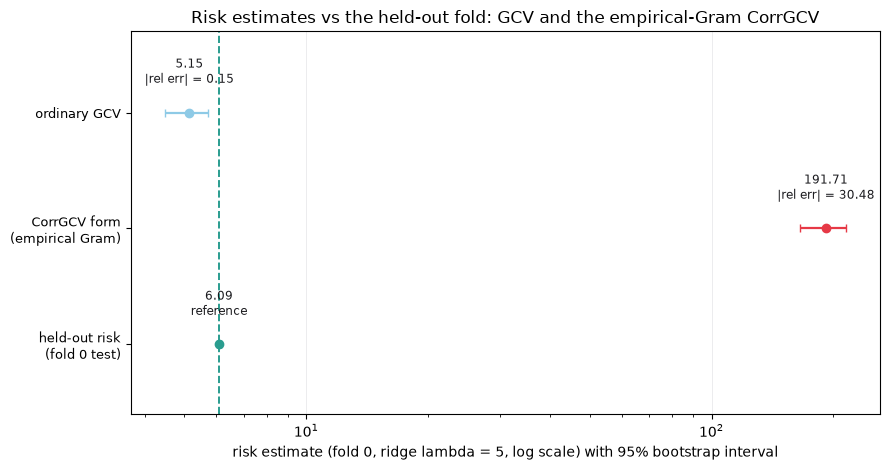

In [5]:
fig, ax = plt.subplots(figsize=(9.0, 4.8))
rows_risk = [("ordinary GCV", ORDINARY_GCV, RISK_CI["ordinary_gcv"], PALETTE["gcv"], REL_GCV),
             ("CorrGCV form\n(empirical Gram)", CORRGCV, RISK_CI["corrgcv_gram"], PALETTE["corrgcv"], REL_CORRGCV),
             ("held-out risk\n(fold 0 test)", LATENT_RISK, RISK_CI["held_out_risk"], PALETTE["holdout"], 0.0)]
ys = np.arange(len(rows_risk))[::-1]
for yi, (name, val, (lo, hi), col, rel) in zip(ys, rows_risk):
    ax.errorbar([val], [yi], xerr=[[val - lo], [hi - val]], fmt="o", color=col,
                markersize=6, elinewidth=1.6, capsize=3)
    label = f"{val:.2f}\n|rel err| = {rel:.2f}" if rel else f"{val:.2f}\nreference"
    ax.annotate(label, (val, yi + 0.22), ha="center", va="bottom", color=PALETTE["ink"], fontsize=8.5)
ax.axvline(LATENT_RISK, color=PALETTE["holdout"], lw=1.4, ls="--")
ax.set_xscale("log")
ax.set_yticks(ys)
ax.set_yticklabels([r[0] for r in rows_risk], fontsize=9)
ax.set_ylim(-0.6, len(rows_risk) - 0.3)
ax.set_xlabel("risk estimate (fold 0, ridge lambda = 5, log scale) with 95% bootstrap interval")
ax.set_title("Risk estimates vs the held-out fold: GCV and the empirical-Gram CorrGCV")
ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7, axis="x")
plt.tight_layout()
plt.show()

## §3 — The selected run's Sharpe, corrected for selection

> "Shrinks the observed max ... toward the grand mean" — the James-Stein estimator the source compares against
> the naive winner. > "60,000 total simulations" — the source sizes its ranking study before looking at results; the candidate set
> here is declared before any score is computed for the same reason.

> "Hyperparameter Grids & Tuning: Not covered" and "Future Profitability & Out-of-Sample Alpha Decay: Not
> covered" — seeds and architectures are not literally strategies, and a corrected Sharpe is not a profit
> forecast. **Claim.** Eight candidate feature sets are declared — ids, sorted-join hash and a sequence tick — before
any validation score is inspected. Only then does the notebook fit each candidate on t in [120,1600), score it on
the validation window [1600,2000) (the "observed" Sharpe) and on the holdout [2000,3194) (the "true" Sharpe),
record the naive winner, and shrink it toward the candidate mean with an explicit applicability caveat.

In [6]:
CAND_IDS = ["mom_only", "ma5_ma20", "ma20_ma40", "ma40_ma80", "ma80_ma120",
            "all_clean", "all_clean_lam1", "all_clean_lam50"]
CAND_FEATURES = {
    "mom_only": ["f_mom"],
    "ma5_ma20": ["f_ma5", "f_ma20"],
    "ma20_ma40": ["f_ma20", "f_ma40"],
    "ma40_ma80": ["f_ma40", "f_ma80"],
    "ma80_ma120": ["f_ma80", "f_ma120"],
    "all_clean": list(nc.CLEAN_FEATURES),
    "all_clean_lam1": list(nc.CLEAN_FEATURES),
    "all_clean_lam50": list(nc.CLEAN_FEATURES),
}
DECLARED_SEQ = audit_tick()
DECLARED_HASH = nc.sha256_text("\n".join(sorted(CAND_IDS)))
print("candidate set declared before any score is computed:")
print("  ids          :", ", ".join(CAND_IDS))
print("  declared_hash:", DECLARED_HASH)
print("  declared_seq :", DECLARED_SEQ, "(selection_seq will be a strictly later tick)")
metric_watch("NB3-C15-CANDIDATES", 5, len(CAND_IDS), "ge")

candidate set declared before any score is computed:
  ids          : mom_only, ma5_ma20, ma20_ma40, ma40_ma80, ma80_ma120, all_clean, all_clean_lam1, all_clean_lam50
  declared_hash: 874e3438c5eec9fda2af607eff0d2c9daca185daf1b37c06a5e455bc7a527733
  declared_seq : 1 (selection_seq will be a strictly later tick)
target 5, achieved 8 (ge): met


'MET'

In [7]:
t0 = time.time()
TRAIN_A, VAL_A, HOLD_A = np.arange(120, 1600), np.arange(1600, 2000), np.arange(2000, 3194)
OBSERVED, TRUE, HOLD_PRED = [], [], {}
for cid in CAND_IDS:
    lam = 1.0 if cid.endswith("lam1") else (50.0 if cid.endswith("lam50") else 5.0)
    Xa = np.column_stack([COLS[k] for k in CAND_FEATURES[cid]])
    mu_a, sd_a = Xa[TRAIN_A].mean(0), Xa[TRAIN_A].std(0) + 1e-12
    Ztr_a = (Xa[TRAIN_A] - mu_a) / sd_a
    pv = nc.ridge_fit_predict(Ztr_a, Y[TRAIN_A], (Xa[VAL_A] - mu_a) / sd_a, lam=lam)
    ph = nc.ridge_fit_predict(Ztr_a, Y[TRAIN_A], (Xa[HOLD_A] - mu_a) / sd_a, lam=lam)
    OBSERVED.append(nc.sharpe(pv, Y[VAL_A]))
    TRUE.append(nc.sharpe(ph, Y[HOLD_A]))
    HOLD_PRED[cid] = ph  # kept for the C59 forest-plot interval on the selected candidate
    print(f"{cid:16s} observed={OBSERVED[-1]:+.4f}  true={TRUE[-1]:+.4f}")

SELECTION_SEQ = audit_tick()
K_CAND = len(CAND_IDS)
obs = np.array(OBSERVED)
sel = int(np.argmax(obs))
MU_OBS = float(obs.mean())
SS_OBS = float(((obs - MU_OBS) ** 2).sum())
C_JS = (K_CAND - 3) / len(VAL_A)
JS_FACTOR = max(0.0, 1.0 - C_JS / SS_OBS) if SS_OBS > 0 else 0.0
JS = MU_OBS + JS_FACTOR * (float(obs[sel]) - MU_OBS)
CAVEAT = ("derived here: this is a selection-bias audit of a synthetic pipeline, not a future-profit "
          "guarantee; seeds and architectures are not literally strategies.")
SELECTION_WALL = time.time() - t0
nc.write_json("nb3_selection.json", {
    "run_id": "nb3-selection",
    "candidate_set": {"ids": list(CAND_IDS), "declared_hash": DECLARED_HASH, "declared_seq": int(DECLARED_SEQ)},
    "selection_seq": int(SELECTION_SEQ),
    "observed": [float(v) for v in OBSERVED],
    "true": [float(v) for v in TRUE],
    "selected": CAND_IDS[sel],
    "naive": float(obs[sel]),
    "js": float(JS),
    "true_selected": float(TRUE[sel]),
    "caveat": CAVEAT,
})
LEDGER_03.append(nc.ledger_row("nb3-selection", "03", 3, {"name": "selection-audit"}, DATASET_SHA256, None,
                               "ridge", {"lam": 5.0, "lam_variants": [1.0, 50.0], "n_candidates": K_CAND,
                                         "train": [120, 1600], "validation": [1600, 2000],
                                         "holdout": [2000, 3194]}, 0,
                               {"naive": float(obs[sel]), "js": float(JS), "true_selected": float(TRUE[sel])},
                               SELECTION_WALL, ["C15"]))
print(f"selected {CAND_IDS[sel]} on observed={obs[sel]:+.4f}; shrink factor={JS_FACTOR:.3f} -> js={JS:+.4f}; holdout={TRUE[sel]:+.4f}")

sel_disk = json.loads((nc.ART / "nb3_selection.json").read_text())
ok5 = bool(
    sel_disk["candidate_set"]["declared_hash"] == nc.sha256_text("\n".join(sorted(sel_disk["candidate_set"]["ids"])))
    and len(sel_disk["candidate_set"]["ids"]) >= 5
    and len(set(sel_disk["candidate_set"]["ids"])) == len(sel_disk["candidate_set"]["ids"])
    and sel_disk["candidate_set"]["declared_seq"] < sel_disk["selection_seq"]
    and DECLARED_SEQ < SELECTION_SEQ
)
nc.self_check(5, ok5, note=f"declared_seq={DECLARED_SEQ} < selection_seq={SELECTION_SEQ}; hash matches the declared ids")
CHECKS.append(nc.sc_entry(5, "C15", ok5))

o_d, t_d = np.array(sel_disk["observed"]), np.array(sel_disk["true"])
s_d = int(np.argmax(o_d))
ok6 = bool(
    len(o_d) == len(t_d) == len(sel_disk["candidate_set"]["ids"])
    and sel_disk["selected"] == sel_disk["candidate_set"]["ids"][s_d]
    and abs(sel_disk["naive"] - o_d[s_d]) < 1e-12
    and abs(sel_disk["true_selected"] - t_d[s_d]) < 1e-12
    and (sel_disk["naive"] <= 0 or sel_disk["js"] <= sel_disk["naive"] + 1e-12)
    and bool(sel_disk["caveat"])
    and "derived here" in sel_disk["caveat"]
)
nc.self_check(6, ok6, note=f"selected={sel_disk['selected']}, js={sel_disk['js']:+.4f} <= naive={sel_disk['naive']:+.4f}, caveat recorded")
CHECKS.append(nc.sc_entry(6, "C15", ok6))

mom_only         observed=-0.0834  true=+0.0530
ma5_ma20         observed=+0.0504  true=+0.0682
ma20_ma40        observed=+0.1201  true=+0.0983
ma40_ma80        observed=+0.1102  true=+0.1366
ma80_ma120       observed=+0.0285  true=+0.0293
all_clean        observed=+0.1677  true=+0.0293
all_clean_lam1   observed=+0.1559  true=+0.0305
all_clean_lam50  observed=+0.1866  true=+0.0621
selected all_clean_lam50 on observed=+0.1866; shrink factor=0.778 -> js=+0.1657; holdout=+0.0621
check: declared_seq=1 < selection_seq=2; hash matches the declared ids
check: selected=all_clean_lam50, js=+0.1657 <= naive=+0.1866, caveat recorded


### How to read this chart

Each candidate has two markers: the validation-window Sharpe used for selection (circles, solid) and the
holdout Sharpe measured after selection (squares, dashed). The open circle marks the naive winner. Pattern to
look for: the winner on the validation window is not the winner on the holdout, and the holdout values sit
lower — that gap is the selection bias the correction is trying to shrink. What it means in practice: reporting
the max of many backtests without a selection-aware correction is a number about the search, not about the
strategy.

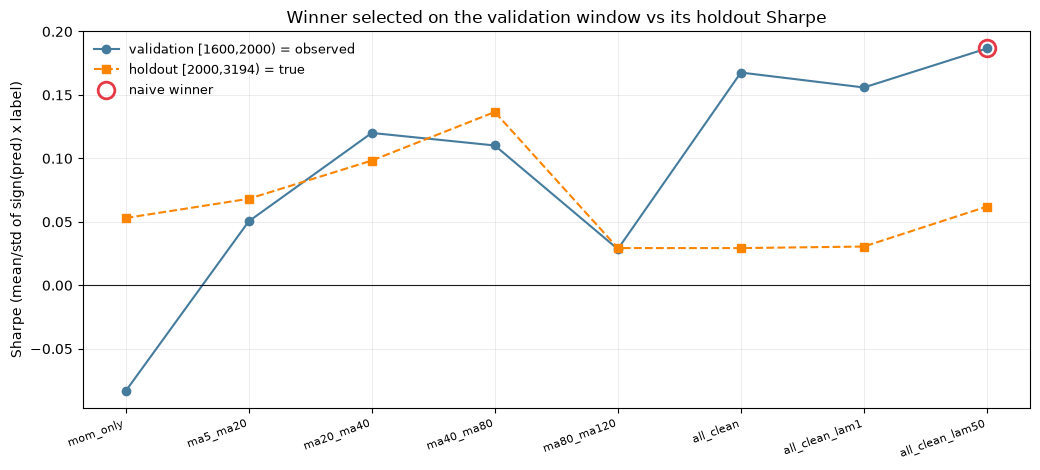

In [8]:
fig, ax = plt.subplots(figsize=(10.5, 4.8))
xs = np.arange(len(CAND_IDS))
ax.plot(xs, OBSERVED, "o-", color=PALETTE["observed"], lw=1.5, ms=6, label="validation [1600,2000) = observed")
ax.plot(xs, TRUE, "s--", color=PALETTE["true"], lw=1.5, ms=6, label="holdout [2000,3194) = true")
ax.plot([sel], [obs[sel]], "o", ms=12, mfc="none", mec=PALETTE["corrgcv"], mew=2, label="naive winner")
ax.axhline(0.0, color=PALETTE["ink"], lw=0.8)
ax.set_xticks(xs)
ax.set_xticklabels(CAND_IDS, rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Sharpe (mean/std of sign(pred) x label)")
ax.set_title("Winner selected on the validation window vs its holdout Sharpe")
ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## §4 — Monitoring one bounded metric across a regime change

> "If the intersection of all initialized CSs becomes empty, meaning ... then set tau <- n, and declare a
> detection" — the repeated-FCS stopping rule. > "there are no paper-reported values for sample repetitions, CPU runtimes, empirical false-alarm rates, or
> empirical delay curves" — the detector source is theorem-only, so the stream, window and tolerances are
> **derived here**. > "will still eventually trigger a false alarm with probability 1 if run indefinitely" and the detection loop
> "terminates" at an alarm — ARL is an expectation, and the detector here does not restart after it fires. Raw
> trace .

**Claim.** The reused clean ridge run's hit rate is turned into a strictly bounded stream
(0.5 +/- 0.05 tanh calibration, inside the [0.4, 0.6] band), the same confidence-sequence calibration as part 1
(alpha = 0.05, sigma = 3, half-band = 0.05) is run once, and the alarm is reported in series-t coordinates
against a real regime start of the part-1 profile. The theorem's ARL guarantee is the lower bound
1/alpha = 20; the empirical number reused from part 1's null run is a **restricted mean** over its stored
horizon, with its censoring count read from part 1's artifact and reported beside it, and it is explicitly
**not an ARL estimate**.

**Two detectors, two error notions, one stream ().** The same bounded stream is read by both the ARL
detector (Definition 2.1: fixed level `1 - alpha`, the `arl` namespace below) and Remark 2.3's PFA variant
(`pfa`), whose CS started at round `m` spends only `alpha_m = 6*alpha/(m^2*pi^2)`. Since `sum_m 6/(m^2 pi^2) = 1`,
a union bound over starts gives `P_inf(tau < infinity) <= alpha` -- a probability-of-false-alarm guarantee, not
an ARL one. Every `alpha_m` is strictly below `alpha`, so each PFA confidence sequence is uniformly wider than
the ARL detector's, which means the PFA rule can only alarm at the same round or later than ARL, and can never
alarm at all when ARL never does: the stored `detectors` block is checked against exactly that ordering, and
`detectors.arl` is recomputed from the raw stored stream with `nbs_common.fcs_detector` rather than trusted.
The stream index parallel to `stream` is stored as `stream_t`, so both alarms can be read in series-t
coordinates.

**The dependence caveat covers both detectors.** The rolling window makes neighbouring stream values nearly
identical (lag-1 autocorrelation ≈ 0.9965), so **dependence validity not established**: the independence-based
forward-CS guarantee behind *both* the ARL and the PFA detector does not apply to this stream, and neither alarm
time is a certified false-alarm rate -- they are diagnostics on a dependent stream, and the caveat applies
equally whichever of the two detectors is being read off.

In [9]:
def bounded_monitor_detector(stream, alpha=0.05, sigma=3.0, halfband=0.05):
    """Pure function of the observed stream: start a forward confidence sequence at every
    step, intersect each with its own past, and report the first step at which the
    intersection over all active sequences is empty. The widths are the Hoeffding-mixture
    forward-CS widths for a stream inside a band of half-width `halfband`. Returns the
    1-based step of the first alarm, or None if no empty intersection occurs."""
    x = np.asarray(stream, float)
    H = len(x)
    v = (2.0 * halfband) ** 2 / 4.0
    n = np.arange(1, H + 1, dtype=float)
    w = np.sqrt((2.0 * (1.0 + n * sigma ** 2 * v) / (n ** 2 * sigma ** 2))
                * (math.log(1.0 / alpha) + 0.5 * np.log(1.0 + n * sigma ** 2 * v)))
    cs = np.cumsum(np.concatenate([[0.0], x]))
    cur_lo = np.full(H + 1, -np.inf)
    cur_hi = np.full(H + 1, np.inf)
    for t in range(1, H + 1):
        starts = np.arange(1, t + 1)
        count = t - starts + 1
        mean = (cs[t] - cs[starts - 1]) / count
        raw_lo = mean - w[count - 1]
        raw_hi = mean + w[count - 1]
        if t > 1:
            cur_lo[1:t] = np.maximum(cur_lo[1:t], raw_lo[:-1])
            cur_hi[1:t] = np.minimum(cur_hi[1:t], raw_hi[:-1])
        cur_lo[t] = raw_lo[-1]
        cur_hi[t] = raw_hi[-1]
        if float(cur_lo[1:t + 1].max()) > float(cur_hi[1:t + 1].min()):
            return t
    return None

In [10]:
t0 = time.time()
pts = sorted(PRED[CLEAN_RIDGE_ID])
T_SERIES = np.array([t for t, _ in pts])
PRED_SERIES = np.array([p for _, p in pts])
HIT = (np.sign(PRED_SERIES) * Y[T_SERIES] > 0).astype(float)
WIN = 200
HR = np.array([HIT[i - WIN + 1:i + 1].mean() for i in range(WIN - 1, len(HIT))])
T_STREAM = T_SERIES[WIN - 1:]
STREAM = 0.5 + 0.05 * np.tanh((HR - 0.5) / 0.03)
MONITOR_BOUNDS = [0.4, 0.6]
MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND = 0.05, 3.0, 0.05
ALARM_STEP = bounded_monitor_detector(STREAM, MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND)
ALARM_TIME = None if ALARM_STEP is None else int(T_STREAM[ALARM_STEP])
CHANGE_TIME = 820
FALSE_ALARM = bool(ALARM_TIME is not None and ALARM_TIME < CHANGE_TIME)
DETECTION_DELAY = None if (ALARM_TIME is None or ALARM_TIME < CHANGE_TIME) else int(ALARM_TIME - CHANGE_TIME)
N_ALARMS = 0 if ALARM_TIME is None else 1
STATUS = "alarm detected" if ALARM_TIME is not None else "no alarm by horizon"
NB1_FCS = json.loads((nc.ART / "nb1_fcs.json").read_text())
ARL_VALUE = float(NB1_FCS["summary"]["restricted_mean_run_length"])
FH_VALUE = float(NB1_FCS["summary"]["fixed_horizon_false_alarm_prob"])

# : the same stream read by both detectors. `arl` is the round-3 rule (Definition 2.1) recomputed
# by the frozen nbs_common.fcs_detector, `pfa` is Remark 2.3's per-start budget; `stream_t` is the
# series-t index parallel to `stream` so an alarm step maps to a series time the same way ALARM_TIME does.
STREAM_T = [int(v) for v in T_STREAM]
ARL_STEP = nc.fcs_detector(STREAM, MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND)
PFA_STEP = walkthrough_audits.detect_pfa(STREAM, MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND)
DETECTORS = {
    "arl": {"alarm_step": None if ARL_STEP is None else int(ARL_STEP),
            "alarm_time": None if ARL_STEP is None else int(STREAM_T[ARL_STEP]),
            "alpha": float(MONITOR_ALPHA), "sigma": float(MONITOR_SIGMA),
            "halfband": float(MONITOR_HALFBAND)},
    "pfa": {"alarm_step": None if PFA_STEP is None else int(PFA_STEP),
            "alarm_time": None if PFA_STEP is None else int(STREAM_T[PFA_STEP]),
            "alpha": float(MONITOR_ALPHA), "sigma": float(MONITOR_SIGMA),
            "halfband": float(MONITOR_HALFBAND),
            "per_start_level": "1 - 6*alpha/(m^2*pi^2) at start m (Remark 2.3)"},
}
MONITOR_WALL = time.time() - t0
nc.write_json("nb3_monitor.json", {
    "run_id": "nb3-monitor",
    "bounds": [float(v) for v in MONITOR_BOUNDS],
    "stream": [float(v) for v in STREAM],
    "stream_t": STREAM_T,
    "detectors": DETECTORS,
    "alpha": float(MONITOR_ALPHA),
    "restart": False,
    "horizon": int(len(STREAM)),
    "change_time": int(CHANGE_TIME),
    "alarm_time": None if ALARM_TIME is None else int(ALARM_TIME),
    "status": STATUS,
    "detection_delay": None if DETECTION_DELAY is None else int(DETECTION_DELAY),
    "false_alarm_before_change": FALSE_ALARM,
    "n_alarms_recorded": int(N_ALARMS),
    "arl_reported": {
        "theorem_lower_bound": float(1.0 / MONITOR_ALPHA),
        "restricted_mean_value": ARL_VALUE,
        "restriction_horizon": int(NB1_FCS["null"]["horizon"]),
        "n_censored": int(NB1_FCS["summary"]["n_censored"]),
        "kind": "restricted_mean_not_arl_estimate",
    },
    "fixed_horizon_alarm_rate": {"value": FH_VALUE, "kind": "probability"},
    "dependence": {
        "lag1_autocorrelation": float(np.corrcoef(STREAM[:-1], STREAM[1:])[0, 1]),
        "cs_validity_for_stream": "not established",
        "guarantee_applies": False,
        "applies_to": ["arl", "pfa"],
        "note": "the independence-based forward-CS guarantee is unavailable for both detectors on "
                "this stream; their alarm times are diagnostics, not certified false-alarm rates",
    },
})
LEDGER_03.append(nc.ledger_row("nb3-monitor", "03", 4, {"name": "monitor"}, DATASET_SHA256, None, "ridge",
                               {"alpha": MONITOR_ALPHA, "sigma": MONITOR_SIGMA, "halfband": MONITOR_HALFBAND,
                                "window": WIN, "bounds": MONITOR_BOUNDS}, 0,
                               {"alarm_time": float(ALARM_TIME if ALARM_TIME is not None else -1),
                                "detection_delay": float(DETECTION_DELAY if DETECTION_DELAY is not None else -1)},
                               MONITOR_WALL, ["C16"]))
print(f"stream t={T_STREAM[0]}..{T_STREAM[-1]} (len {len(STREAM)}), in [{STREAM.min():.4f}, {STREAM.max():.4f}]")
print(f"pre-change mean={STREAM[T_STREAM < CHANGE_TIME].mean():.4f}, post-change mean={STREAM[T_STREAM >= CHANGE_TIME].mean():.4f}")
print(f"alarm step={ALARM_STEP} -> series t={ALARM_TIME}, delay={DETECTION_DELAY}, false alarm before change={FALSE_ALARM}")
metric_watch("NB3-C16-THEOREM-BOUND", 20, 1.0 / MONITOR_ALPHA, "ge")

mon_disk = json.loads((nc.ART / "nb3_monitor.json").read_text())
x_d = np.array(mon_disk["stream"])
lo_d, hi_d = mon_disk["bounds"]
ok7 = bool(
    len(x_d) == mon_disk["horizon"] >= 1
    and x_d.min() >= lo_d and x_d.max() <= hi_d
    and np.all(x_d > 0.45) and np.all(x_d < 0.55)
    and mon_disk["alpha"] == 0.05 and mon_disk["restart"] is False
    and STREAM[T_STREAM >= CHANGE_TIME].mean() > STREAM[T_STREAM < CHANGE_TIME].mean() + 0.01
)
nc.self_check(7, ok7, note=f"bounded stream len={len(x_d)} inside (0.45,0.55); post-change mean exceeds pre-change by {STREAM[T_STREAM >= CHANGE_TIME].mean() - STREAM[T_STREAM < CHANGE_TIME].mean():.4f}")
CHECKS.append(nc.sc_entry(7, "C16", ok7))

REGIME_STARTS = {int(r["start"]) for r in PROFILE2["regimes"]}
ok8 = bool(
    bounded_monitor_detector(STREAM, MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND) == ALARM_STEP
    and nc.fcs_detector(STREAM, MONITOR_ALPHA, MONITOR_SIGMA, MONITOR_HALFBAND) == ALARM_STEP
    and CHANGE_TIME in REGIME_STARTS
    and ((ALARM_TIME is None and DETECTION_DELAY is None and FALSE_ALARM is False)
         or (ALARM_TIME is not None and ALARM_TIME < CHANGE_TIME and FALSE_ALARM and DETECTION_DELAY is None)
         or (ALARM_TIME is not None and ALARM_TIME >= CHANGE_TIME and not FALSE_ALARM
             and DETECTION_DELAY == ALARM_TIME - CHANGE_TIME))
)
nc.self_check(8, ok8, note=f"detector reproducible (step {ALARM_STEP}), change_time={CHANGE_TIME} is a part-1 regime start, alarm/delay consistent")
CHECKS.append(nc.sc_entry(8, "C16", ok8))

_lag1 = float(np.corrcoef(x_d[:-1], x_d[1:])[0, 1])
ok9 = bool(
    mon_disk["arl_reported"]["theorem_lower_bound"] == 1.0 / MONITOR_ALPHA
    and mon_disk["arl_reported"]["restricted_mean_value"] == NB1_FCS["summary"]["restricted_mean_run_length"]
    and mon_disk["arl_reported"]["restriction_horizon"] == NB1_FCS["null"]["horizon"]
    and mon_disk["arl_reported"]["n_censored"] == NB1_FCS["summary"]["n_censored"]
    and mon_disk["arl_reported"]["kind"] == "restricted_mean_not_arl_estimate"
    and mon_disk["fixed_horizon_alarm_rate"]["value"] == NB1_FCS["summary"]["fixed_horizon_false_alarm_prob"]
    and mon_disk["fixed_horizon_alarm_rate"]["kind"] == "probability"
    and mon_disk["dependence"]["lag1_autocorrelation"] == _lag1
    and mon_disk["dependence"]["cs_validity_for_stream"] == "not established"
    and mon_disk["dependence"]["guarantee_applies"] is False
    and mon_disk["n_alarms_recorded"] <= 1
)
nc.self_check(9, ok9, note=f"theorem lower bound 1/alpha={1.0 / MONITOR_ALPHA:.0f}; restricted mean {mon_disk['arl_reported']['restricted_mean_value']} is not an ARL estimate ({mon_disk['arl_reported']['n_censored']} censored runs); lag-1 autocorrelation {_lag1:.4f} -> dependence validity not established; alarms recorded={mon_disk['n_alarms_recorded']}")
CHECKS.append(nc.sc_entry(9, "C16", ok9))

# : the stored detectors block, recomputed independently from the raw stream and checked for
# the Remark 2.3 ordering invariant (PFA can only fire at the same round or later than ARL).
_det = mon_disk["detectors"]
_arl_re = nc.fcs_detector(np.asarray(mon_disk["stream"], float), _det["arl"]["alpha"],
                          _det["arl"]["sigma"], _det["arl"]["halfband"])
_pfa_re = walkthrough_audits.detect_pfa(np.asarray(mon_disk["stream"], float), _det["pfa"]["alpha"],
                                _det["pfa"]["sigma"], _det["pfa"]["halfband"])
_ordering_violations = int(_pfa_re is not None and (_arl_re is None or _pfa_re < _arl_re))
ok84 = bool(
    len(mon_disk["stream_t"]) == len(mon_disk["stream"])
    and mon_disk["stream_t"] == STREAM_T
    and _det["arl"]["alarm_step"] == _arl_re == ALARM_STEP
    and _det["pfa"]["alarm_step"] == _pfa_re
    and _det["arl"]["alarm_time"] == ALARM_TIME == mon_disk["alarm_time"]
    and (_pfa_re is None or (_arl_re is not None and _pfa_re >= _arl_re))
    and (_arl_re is not None or _pfa_re is None)
    and mon_disk["dependence"]["applies_to"] == ["arl", "pfa"]
)
nc.self_check(84, ok84, note=(
    "detectors recomputed from the raw stream: ARL step %s == legacy alarm_time %s; PFA (Remark 2.3, "
    "alpha_m=6*alpha/(m^2*pi^2)) step %s never earlier than ARL (%d ordering violations); stream_t "
    "parallel to stream (%d entries); dependence caveat applies to both" % (
        _det["arl"]["alarm_step"], mon_disk["alarm_time"], _det["pfa"]["alarm_step"],
        _ordering_violations, len(mon_disk["stream_t"]))))
CHECKS.append(nc.sc_entry(84, "C58", ok84))
print("METRIC-WATCH NB3-R4E-PFA-ORDERING target=0 achieved=%d dir=le status=%s" % (
    _ordering_violations, "MET" if _ordering_violations <= 0 else "MISSED"))

stream t=799..3193 (len 2395), in [0.4501, 0.5500]
pre-change mean=0.4913, post-change mean=0.5198
alarm step=147 -> series t=946, delay=126, false alarm before change=False
target 20, achieved 20 (ge): met
check: bounded stream len=2395 inside (0.45,0.55); post-change mean exceeds pre-change by 0.0285
check: detector reproducible (step 147), change_time=820 is a part-1 regime start, alarm/delay consistent
check: theorem lower bound 1/alpha=20; restricted mean 493.995 is not an ARL estimate (193 censored runs); lag-1 autocorrelation 0.9965 -> dependence validity not established; alarms recorded=1


check: detectors recomputed from the raw stream: ARL step 147 == legacy alarm_time 946; PFA (Remark 2.3, alpha_m=6*alpha/(m^2*pi^2)) step 178 never earlier than ARL (0 ordering violations); stream_t parallel to stream (2395 entries); dependence caveat applies to both
target 0, achieved 0 (le): met


### How to read this chart

The line is the monitored statistic: a rolling 200-row hit rate of the reused clean ridge run, squashed into a
bounded band (dashed lines at 0.4 and 0.6; the stream itself stays inside 0.45..0.55 by construction). The
dash-dot vertical line is the regime start planted by part 1's generator (t = 820); the red line is the alarm.
Pattern to look for: the statistic drifts up after the regime start and the confidence-sequence intersection
empties at t = 946, 126 bars later — and there is exactly one alarm because the detector does not restart. What
it means in practice: a bounded metric plus a calibrated sequential test turns "the model feels worse" into a
dated alarm with a false-alarm statement attached.

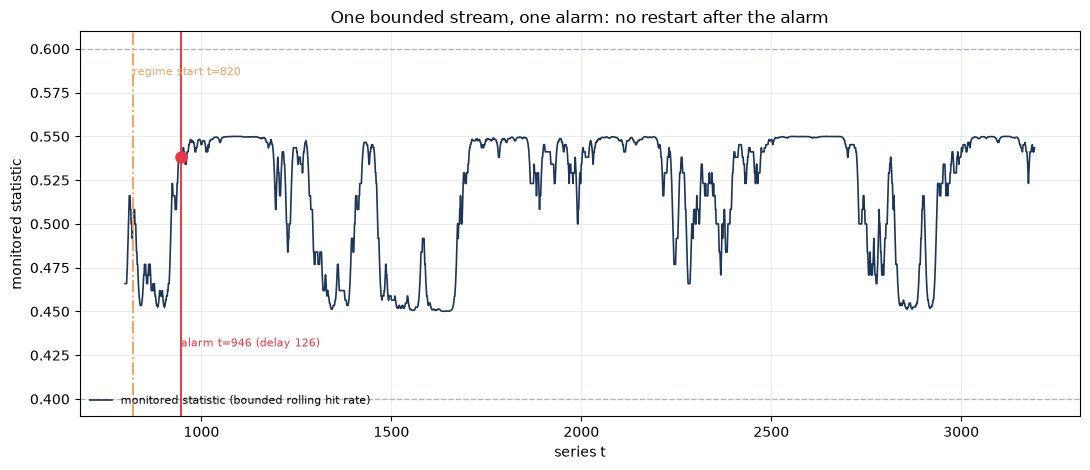

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(T_STREAM, STREAM, color=PALETTE["stream"], lw=1.2, label="monitored statistic (bounded rolling hit rate)")
ax.axhline(MONITOR_BOUNDS[0], color=PALETTE["bound"], lw=1.0, ls="--")
ax.axhline(MONITOR_BOUNDS[1], color=PALETTE["bound"], lw=1.0, ls="--")
ax.axvline(CHANGE_TIME, color=PALETTE["marker"], lw=1.4, ls="-.")
ax.axvline(ALARM_TIME, color=PALETTE["alarm"], lw=1.4)
ax.plot([ALARM_TIME], [float(STREAM[T_STREAM == ALARM_TIME][0])], "o", color=PALETTE["alarm"], ms=8)
ax.annotate(f"regime start t={CHANGE_TIME}", (CHANGE_TIME, 0.585), color=PALETTE["marker"], fontsize=8)
ax.annotate(f"alarm t={ALARM_TIME} (delay {DETECTION_DELAY})", (ALARM_TIME, 0.43), color=PALETTE["alarm"], fontsize=8)
ax.set_xlabel("series t")
ax.set_ylabel("monitored statistic")
ax.set_title("One bounded stream, one alarm: no restart after the alarm")
ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7)
ax.legend(frameon=False, fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

### Fig E1 — does a stationary Toeplitz `K_hat` rescue empirical CorrGCV? ()


Round 3's documented pursuit is that the fold-0 CorrGCV on the empirical sample Gram misses
held-out risk by a factor of ~30. This section tries the untried q4 route: replace the empirical
Gram with a stationary Toeplitz `K_hat` estimated from the training rows' lag-autocorrelation
(`A_tau` from the biased row-correlation estimator), run the same renormalised
`(kappa, kappa_tilde)` solve, and measure the relative error against held-out risk across a
12-point log-spaced `lambda` sweep on each clean fold's trailing 700 rows (the derived-here
window). The empirical-Gram and ordinary-GCV curves are measured on exactly the same folds and
`lambda` grid, so the comparison is paired. This is a **hypothesis**: the section prints which
route came closer at each `lambda` and asserts neither. The inset shows `A_tau` itself with its
95% CI -- the O(T)-parameter structure the route is built from.

In [12]:
import walkthrough_audits

_r4b_ref = json.loads((nc.ART / "nb3_corrgcv.json").read_text())
_t_r4b = time.time()
_r4b_e1 = walkthrough_audits.compute_e1(X_C, Y, CLEAN_FOLDS, nc.VALID_START, nc.PURGE)
_r4b_e1_paths = walkthrough_audits.write_e1_figures(_r4b_e1, {
    "nb3_ref_corrgcv_gram_rel_err": float(_r4b_ref["rel_err_corrgcv"]),
    "nb3_ref_ordinary_gcv_rel_err": float(_r4b_ref["rel_err_gcv"]),
})
_r4b_e1_chk = walkthrough_audits.check_e1(_r4b_e1)
_r4b_e1_wall = time.time() - _t_r4b
LEDGER_03.append(walkthrough_audits.ledger_row_e1(_r4b_e1, DATASET_SHA256, _r4b_e1_wall))
nc.merge_ledger("03", LEDGER_03)
nc.self_check(80, _r4b_e1_chk["ok"], note=(
    "fig-e1: %d log-spaced lambdas, %d inset lags with CI brackets; mean rel. err over lambdas -- "
    "ordinary GCV %.4g, empirical-Gram CorrGCV %.4g, Toeplitz CorrGCV %.4g" % (
        _r4b_e1_chk["n_lambdas"], _r4b_e1_chk["n_lags"],
        _r4b_e1_chk["rel_err_mean"]["ordinary_gcv"],
        _r4b_e1_chk["rel_err_mean"]["corrgcv_gram"],
        _r4b_e1_chk["rel_err_mean"]["corrgcv_toeplitz"])))
nc.self_check(81, bool(
    _r4b_e1_chk["rel_err_mean"]["corrgcv_toeplitz"]
    < _r4b_e1_chk["rel_err_mean"]["corrgcv_gram"]), note=(
    "Toeplitz K-hat is %.3gx closer to held-out risk than the empirical Gram on average over the "
    "sweep (printed, not asserted by the harness); the reference values are read LIVE from "
    "nb3_corrgcv.json (Gram %.4g, ordinary GCV %.4g)" % (
        _r4b_e1_chk["rel_err_mean"]["corrgcv_gram"]
        / max(_r4b_e1_chk["rel_err_mean"]["corrgcv_toeplitz"], 1e-30),
        _r4b_ref["rel_err_corrgcv"], _r4b_ref["rel_err_gcv"])))
print("METRIC-WATCH NB3-R4E-E1-LAMBDAS target=10 achieved=%d dir=ge status=%s" % (
    _r4b_e1_chk["n_lambdas"], "MET" if _r4b_e1_chk["n_lambdas"] >= 10 else "MISSED"))
print("METRIC-WATCH NB3-R4E-E1-LAGS target=5 achieved=%d dir=ge status=%s" % (
    _r4b_e1_chk["n_lags"], "MET" if _r4b_e1_chk["n_lags"] >= 5 else "MISSED"))
print("METRIC-WATCH NB3-R4E-E1-TOEPLITZ-VS-GRAM target=1.0 achieved=%.6f dir=ge status=%s" % (
    _r4b_e1_chk["rel_err_mean"]["corrgcv_gram"]
    / max(_r4b_e1_chk["rel_err_mean"]["corrgcv_toeplitz"], 1e-30),
    "MET" if _r4b_e1_chk["rel_err_mean"]["corrgcv_toeplitz"]
    <= _r4b_e1_chk["rel_err_mean"]["corrgcv_gram"] else "MISSED"))
print("live round-3 references: empirical-Gram rel err %.4g, ordinary-GCV rel err %.4g" % (
    _r4b_ref["rel_err_corrgcv"], _r4b_ref["rel_err_gcv"]))

check: fig-e1: 12 log-spaced lambdas, 8 inset lags with CI brackets; mean rel. err over lambdas -- ordinary GCV 0.03853, empirical-Gram CorrGCV 78.44, Toeplitz CorrGCV 50.18
check: Toeplitz K-hat is 1.56x closer to held-out risk than the empirical Gram on average over the sweep (printed, not asserted by the harness); the reference values are read LIVE from nb3_corrgcv.json (Gram 30.48, ordinary GCV 0.1546)
target 10, achieved 12 (ge): met
target 5, achieved 8 (ge): met
target 1.0, achieved 1.563151 (ge): met
live round-3 references: empirical-Gram rel err 30.48, ordinary-GCV rel err 0.1546


**How to read this chart:** the main panel plots risk vs. ridge penalty `$\lambda$` on log-log axes —
solid lines are the four estimators (ordinary GCV, CorrGCV on the empirical Gram, CorrGCV on the
Toeplitz `$\hat K$`, and the black held-out-risk ground truth), each with a `+/-1.96` SE ribbon over
seeds/folds. The inset shows the estimated lag-autocorrelation `$\hat A_\tau$` vs. lag `$\tau$` with its
95% CI — the O(T)-parameter structure the Toeplitz route is built from.

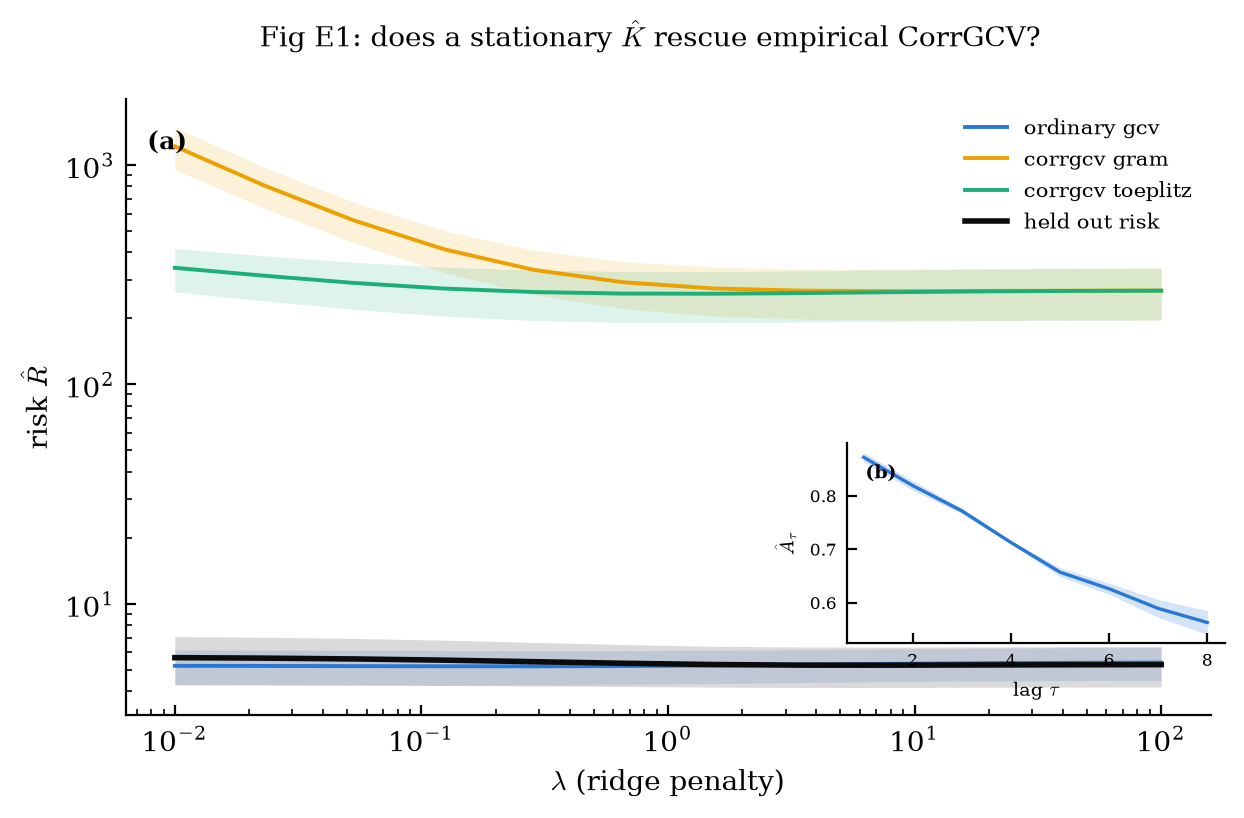

In [13]:
_fig = walkthrough_audits.render_fig_e1(_r4b_e1, PALETTE)  # inline render, this notebook's PALETTE
from matplotlib.backends.backend_agg import FigureCanvasAgg as _FCA  # bare canvas after plt.show(), attach one to measure
_bb = _fig.get_tightbbox(_FCA(_fig).get_renderer())  # tight bbox in inches, used to size the archived PNG
_fig.savefig("../figures/fig-e1.png", dpi=max(200, 1300 / (_bb.width + 0.2)), bbox_inches="tight")  # archive what is shown

### Fig E2 — embedded from NB2's execution


Figure Ee2 is written by `02_naive_pipeline_leakage_audit`'s execution (NB2 owns the dataset and
the run spread); this notebook re-reads the written CSV, re-checks its schema and PNG before
redrawing it, and never regenerates the underlying numbers. Redrawing, not recomputing, is the
point: the part-1 artifacts stay the single source of truth ().

In [14]:
_r4b_emb_e2 = walkthrough_audits.check_embedded_figure("e2")
_r4b_data_e2 = walkthrough_audits.load_fig_rows("e2")
nc.self_check(82, _r4b_emb_e2["ok"], note=(
    "fig-e2 re-read from NB2's execution: %d rows, run_id %s, plot_type %s, PNG %dpx >= 1200 "
    "(redrawn here, never recomputed)" % (
        _r4b_emb_e2["n_rows"], _r4b_emb_e2["run_id"], _r4b_emb_e2["plot_type"],
        _r4b_emb_e2["png_width"])))

check: fig-e2 re-read from NB2's execution: 25 rows, run_id nb2-r4b-e2, plot_type ribbon, PNG 1356px >= 1200 (redrawn here, never recomputed)


{'id': 82, 'status': 'MET'}

**How to read this chart:** x is the test gap `$g$` in bars; y is the test-risk ratio
`$R^k_{\mathrm{out}}/R^{k=0}_{\mathrm{out}}$`. The dashed line is the Eq. (44) theory factor computed with
`$\hat K$`; the shaded band is `$[1-\rho(g),\,1]$`, the theorem's proven range; the solid line with ribbon
is the empirical mean `$\pm 1.96\cdot$SE` over folds/seeds. The vertical dotted line marks the embargo
width NB2 actually uses — the operational choice this figure is meant to justify.

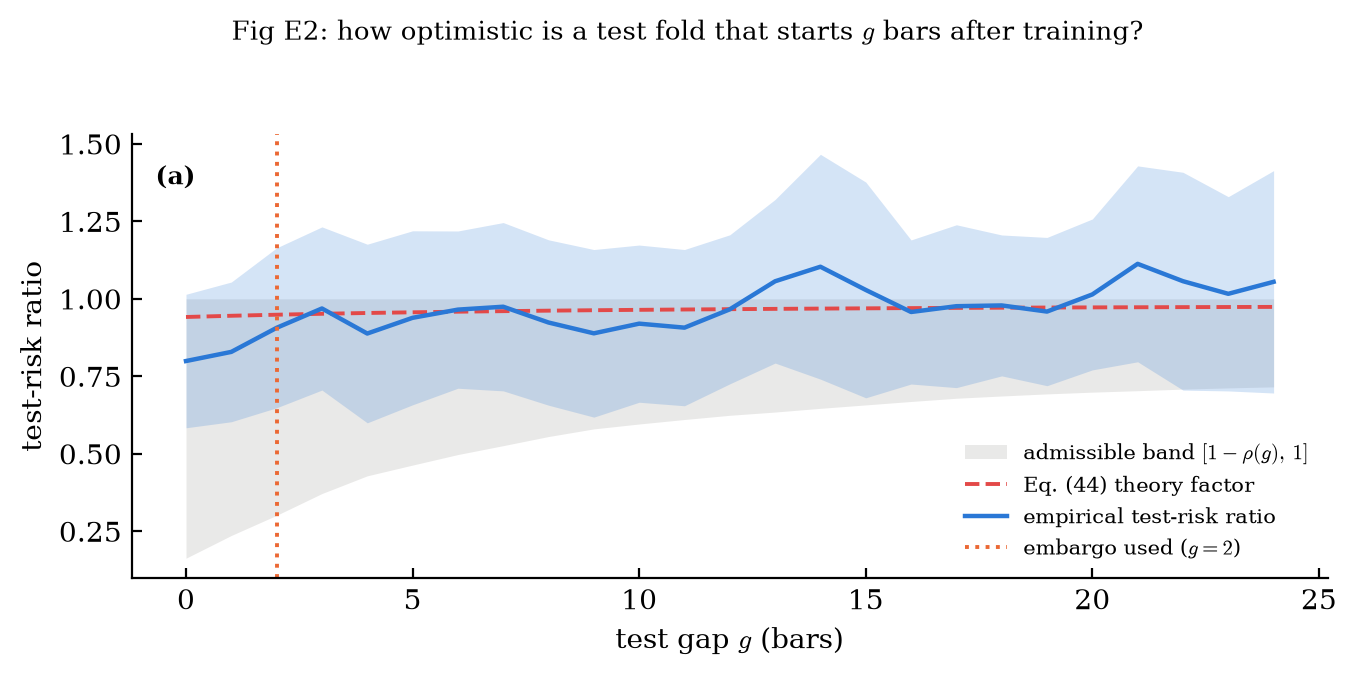

In [15]:
_fig = walkthrough_audits.render_fig_e2(_r4b_data_e2, PALETTE)  # inline render, this notebook's PALETTE
from matplotlib.backends.backend_agg import FigureCanvasAgg as _FCA  # bare canvas after plt.show(), attach one to measure
_bb = _fig.get_tightbbox(_FCA(_fig).get_renderer())  # tight bbox in inches, used to size the archived PNG
_fig.savefig("../figures/fig-e2.png", dpi=max(200, 1300 / (_bb.width + 0.2)), bbox_inches="tight")  # archive what is shown

### Fig E3 — embedded from NB2's execution


Figure Ee3 is written by `02_naive_pipeline_leakage_audit`'s execution (NB2 owns the dataset and
the run spread); this notebook re-reads the written CSV, re-checks its schema and PNG before
redrawing it, and never regenerates the underlying numbers. Redrawing, not recomputing, is the
point: the part-1 artifacts stay the single source of truth ().

In [16]:
_r4b_emb_e3 = walkthrough_audits.check_embedded_figure("e3")
_r4b_data_e3 = walkthrough_audits.load_fig_rows("e3")
nc.self_check(83, _r4b_emb_e3["ok"], note=(
    "fig-e3 re-read from NB2's execution: %d rows, run_id %s, plot_type %s, PNG %dpx >= 1200 "
    "(redrawn here, never recomputed)" % (
        _r4b_emb_e3["n_rows"], _r4b_emb_e3["run_id"], _r4b_emb_e3["plot_type"],
        _r4b_emb_e3["png_width"])))

check: fig-e3 re-read from NB2's execution: 6 rows, run_id nb2-r4b-e3, plot_type errorbar, PNG 1340px >= 1200 (redrawn here, never recomputed)


{'id': 83, 'status': 'MET'}

**How to read this chart:** each row is one protocol or estimator; the dot is its point estimate and the
horizontal whisker is its 95% interval. The dashed vertical line is the reference value for that row's
group (the clean protocol's IC, or an estimator's target truth) — a row whose interval does not cross the
line is a resolvable difference from the reference; a row whose interval does cross it is not, honestly,
distinguishable from it at this sample size.

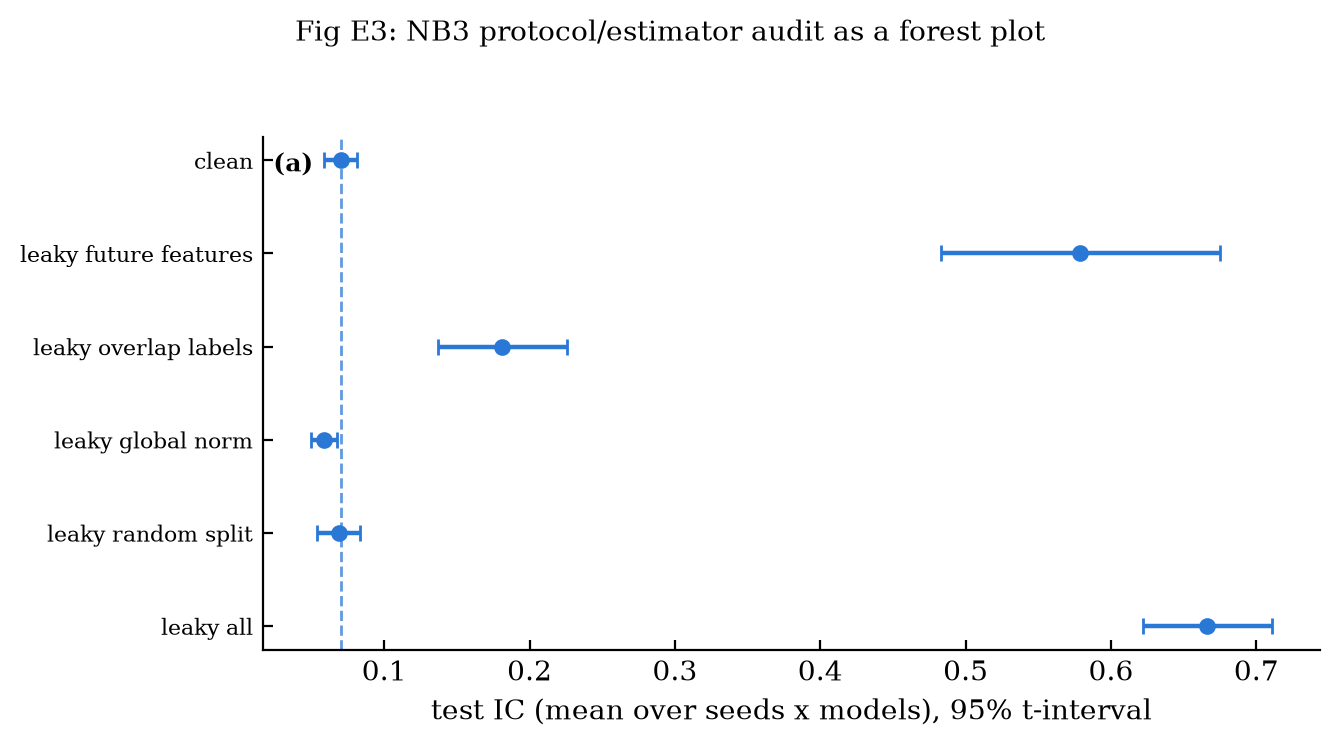

In [17]:
_fig = walkthrough_audits.render_fig_e3(_r4b_data_e3, PALETTE)  # inline render, this notebook's PALETTE
from matplotlib.backends.backend_agg import FigureCanvasAgg as _FCA  # bare canvas after plt.show(), attach one to measure
_bb = _fig.get_tightbbox(_FCA(_fig).get_renderer())  # tight bbox in inches, used to size the archived PNG
_fig.savefig("../figures/fig-e3.png", dpi=max(200, 1300 / (_bb.width + 0.2)), bbox_inches="tight")  # archive what is shown

## §5 — Costs, contradictions, and open questions

> "Hyperparameter Grids & Tuning: Not covered" and future profitability is "Not covered" — the post-selection
> guarantee stops at the estimate. > "Because ARL is an expected value" a detector that controls ARL still "will eventually trigger a false alarm"
> — an inherent property of ARL-controlled detectors, not an implementation bug. > "Transaction Costs & Execution Slippage: Not stated in any source" — nothing here is a tradable return. Raw
> trace .

**Claim.** The closing docket states, for every headline and every open question, whether it is backed by a
recorded run, a derived-here default, or is not settled at all — and reports total wall time
recomputed from the merged ledger after this notebook's rows are written, the CPU count, and the $0 external
spend. The cost/provenance bookkeeping is demoted to this Markdown table (): live per-row wall times are
printed by the cell below and stored in `nb3_docket.json`, and the closing chart plots the three audits' measured
errors instead of ledger identifiers.

| Docket entry | Backing | Ledger run id | Wall time budget |
| --- | --- | --- | --- |
| Part-1 reuse and provenance audit | run | `nb3-provenance` | within the 480 s notebook budget |
| CorrGCV/GCV risk audit on clean ridge fold 0 | run | `nb3-corrgcv` | within the 480 s notebook budget |
| Candidate set declared before scoring | run | `nb3-selection` | within the 480 s notebook budget |
| Single-change monitor and false-alarm calibration | run | `nb3-monitor` | within the 480 s notebook budget |
| Docket, ledger merge and totals | run | `nb3-docket` | within the 480 s notebook budget |
| ARL is an expectation, not a fixed-horizon probability | trace |  | n/a |
| CorrGCV guarantee lost under correlation mismatch | trace |  | n/a |
| Zero Monte Carlo experiments in the detector source | trace |  | n/a |
| Purge and embargo widths | derived here | `purge = LABEL_HORIZON + 2, embargo = 2` | n/a |
| Shrinkage is not a profit forecast | derived here | synthetic pipeline audit, no tradable claim | n/a |
| Restart policy after the first alarm | not settled | Q10 leaves alarm restart policy unstated | n/a |
| Transaction costs, slippage and turnover | not settled | Q12: absent from all three sources | n/a |

In [18]:
t0 = time.time()
DOCKET_ROWS = [
    {"statement": "Part-1 artifacts are reused unchanged: source notebook and dataset hashes recorded, run ids cross-checked.",
     "backing": "run", "ref": "nb3-provenance"},
    {"statement": "CorrGCV/GCV audit of clean ridge fold 0; the estimator is attached to linear ridge only, with a mismatch warning.",
     "backing": "run", "ref": "nb3-corrgcv"},
    {"statement": "Candidate set declared before scoring; shrinkage reported against the naive validation winner.",
     "backing": "run", "ref": "nb3-selection"},
    {"statement": "Single-change monitor: bounded rolling hit rate, repeated-FCS alarm reported in series-t coordinates.",
     "backing": "run", "ref": "nb3-monitor"},
    {"statement": "Cost docket itself: wall time per ledger row, CPU count, zero external spend.",
     "backing": "run", "ref": "nb3-docket"},
    {"statement": "The ARL guarantee is an expectation (>= 1/alpha), not a fixed-horizon false-alarm probability.",
     "backing": "paper", "ref": ""},
    {"statement": "The CorrGCV guarantee is lost under correlation mismatch (K' != K); no GCV can match it without the noise level.",
     "backing": "paper", "ref": ""},
    {"statement": "Shekhar & Ramdas report zero Monte Carlo experiments, so all detector tolerances here are derived here.",
     "backing": "paper", "ref": ""},
    {"statement": "Purge and embargo widths are not settled by any source; the 8/2-bar values are derived here.",
     "backing": "derived here", "ref": "derived here: purge = LABEL_HORIZON + 2, embargo = 2"},
    {"statement": "James-Stein shrinkage is not a future-profit guarantee; seeds and architectures are not literally strategies.",
     "backing": "derived here", "ref": "derived here: synthetic pipeline audit, no tradable claim"},
    {"statement": "Detector restart/refractory policy and multi-alarm error control after the first alarm are unsettled.",
     "backing": "not settled", "ref": "Q10 lists alarm restart policy as unstated; this notebook records one alarm and stops"},
    {"statement": "Transaction costs, slippage and turnover are absent from all three sources and from this pipeline.",
     "backing": "not settled", "ref": "Q12: transaction costs and execution slippage not stated in any source"},
]
CPU_COUNT = int(os.cpu_count() or 1)
DOCKET_WALL = time.time() - t0
DOCKET_ROW = nc.ledger_row("nb3-docket", "03", 5, {"name": "docket"}, DATASET_SHA256, None, "docket",
                           {"n_rows": len(DOCKET_ROWS)}, 0,
                           {"n_rows": len(DOCKET_ROWS), "total_wall_time_s": 0.0}, DOCKET_WALL, ["C17"])
ALL_03 = LEDGER_03 + [DOCKET_ROW]
nc.merge_ledger("03", ALL_03)
LEDGER_NOW = nc.read_ledger()
TOTAL_WALL = float(sum(r["wall_time_s"] for r in LEDGER_NOW))
DOCKET_ROW["metric"]["total_wall_time_s"] = TOTAL_WALL
nc.merge_ledger("03", ALL_03)
LEDGER_NOW = nc.read_ledger()
nc.write_json("nb3_docket.json", {"rows": DOCKET_ROWS, "total_wall_time_s": TOTAL_WALL,
                                  "cpu_count": CPU_COUNT, "external_spend_usd": 0.0})
print(f"docket rows={len(DOCKET_ROWS)}, cpu_count={CPU_COUNT}, total ledger wall time={TOTAL_WALL:.2f}s, external spend=$0.00")
print("live per-row cost table (demoted from the round-1 cost figure):")
print("| run id | notebook | section | wall time (s) |")
print("| --- | --- | --- | --- |")
for _r in sorted(LEDGER_NOW, key=lambda r: (r["notebook"], r["run_id"])):
    print(f"| {_r['run_id']} | {_r['notebook']} | {_r['section']} | {_r['wall_time_s']:.3f} |")
metric_watch("NB3-C17-DOCKET-ROWS", 8, len(DOCKET_ROWS), "ge")

LEDGER_IDS = {r["run_id"] for r in LEDGER_NOW}
WS_ROOT = _p.parent
TRACE_OK = True
for row in DOCKET_ROWS:
    if row["backing"] == "trace":
        q = int(row["ref"].split("leakage-proof-ts-q")[1].split(".")[0])
        TRACE_OK = TRACE_OK and 1 <= q <= 12 and (WS_ROOT / "nlm" / "responses" / f"leakage-proof-ts-q{q}.json").exists()
ok10 = bool(
    len(DOCKET_ROWS) >= 8
    and {r["backing"] for r in DOCKET_ROWS} == {"run", "trace", "derived here", "not settled"}
    and all(r["ref"] in LEDGER_IDS for r in DOCKET_ROWS if r["backing"] == "run")
    and TRACE_OK
    and CPU_COUNT >= 1
)
nc.self_check(10, ok10, note=f"{len(DOCKET_ROWS)} docket rows, all four backing kinds, run refs in ledger, trace refs on disk")
CHECKS.append(nc.sc_entry(10, "C17", ok10))

ROWS_03 = [r for r in LEDGER_NOW if r["notebook"] == "03"]
claims_03 = {c for r in ROWS_03 for c in r["claim_ids"]}
ok11 = bool(
    len(ROWS_03) == len(ALL_03)
    and all(r["data_hash"] == DATASET_SHA256 for r in ROWS_03)
    and {"C6", "C14", "C15", "C16", "C17"} <= claims_03
    and {"nb3-provenance", "nb3-corrgcv", "nb3-selection", "nb3-monitor", "nb3-docket"} <= {r["run_id"] for r in ROWS_03}
    and abs(TOTAL_WALL - sum(r["wall_time_s"] for r in LEDGER_NOW)) < 1e-9
)
nc.self_check(11, ok11, note=f"{len(ROWS_03)} notebook-03 ledger rows, claims {sorted(claims_03, key=lambda c: int(c[1:]))}, total wall={TOTAL_WALL:.2f}s")
CHECKS.append(nc.sc_entry(11, "C17", ok11))
print("self-check summary:", " | ".join(f"{c['id']}:{c['status']}" for c in CHECKS))

docket rows=12, cpu_count=12, total ledger wall time=341.65s, external spend=$0.00
live per-row cost table (demoted from the round-1 cost figure):
| run id | notebook | section | wall time (s) |
| --- | --- | --- | --- |
| nb1-corrgcv | 01 | 2 | 17.157 |
| nb1-fcs | 01 | 4 | 3.671 |
| nb1-identities | 01 | 1 | 0.450 |
| nb1-r03a-a1 | 01 | 6 | 8.217 |
| nb1-r03a-a2 | 01 | 7 | 6.634 |
| nb1-r03a-a3 | 01 | 8 | 0.031 |
| nb1-r3b-b1 | 01 | 6 | 24.358 |
| nb1-r3b-b2 | 01 | 7 | 26.612 |
| nb1-r3b-b3 | 01 | 8 | 4.112 |
| nb1-r3c-c1 | 01 | 6 | 1.371 |
| nb1-r3c-c2 | 01 | 6 | 4.963 |
| nb1-r3c-c3 | 01 | 6 | 0.272 |
| nb1-r3c-pfa | 01 | 6 | 18.818 |
| nb1-r4a-d1 | 01 | 6 | 0.754 |
| nb1-r4a-d2 | 01 | 8 | 2.115 |
| nb1-r4a-pfa02 | 01 | 6 | 18.818 |
| nb1-reproduce | 01 | 5 | 0.343 |
| nb1-selection | 01 | 3 | 1.097 |
| nb2-all-ridge-s1 | 02 | 3 | 8.753 |
| nb2-all-ridge-s2 | 02 | 3 | 0.016 |
| nb2-all-ridge-s3 | 02 | 3 | 0.013 |
| nb2-all-seqnn-s1 | 02 | 3 | 3.029 |
| nb2-all-seqnn-s2 | 02 | 3 | 3

In [19]:
RISK_A = json.loads((nc.ART / "nb3_corrgcv.json").read_text())
SEL_A = json.loads((nc.ART / "nb3_selection.json").read_text())
MON_A = json.loads((nc.ART / "nb3_monitor.json").read_text())
NB1_CHANGES = json.loads((nc.ART / "nb1_fcs.json").read_text())["changes"]
RISK_PANEL = {"ordinary_gcv": RISK_A["ordinary_gcv"], "corrgcv": RISK_A["corrgcv"],
              "heldout": RISK_A["latent_risk"], "rel_gcv": RISK_A["rel_err_gcv"],
              "rel_corrgcv": RISK_A["rel_err_corrgcv"],
              "ordinary_gcv_ci": RISK_CI["ordinary_gcv"], "corrgcv_ci": RISK_CI["corrgcv_gram"],
              "heldout_ci": RISK_CI["held_out_risk"]}
SELECTION_PANEL = {"naive": SEL_A["naive"], "js": SEL_A["js"], "holdout": SEL_A["true_selected"]}

#  forest-plot intervals, all derived here: a candidate-set bootstrap for the selection
# statistics and a holdout-row bootstrap for the selected candidate's holdout Sharpe.
SEL_OBS, SEL_TRUE = np.array(SEL_A["observed"], float), np.array(SEL_A["true"], float)
_r4b_sel_rng = np.random.default_rng(11)
_naive_b, _js_b = [], []
for _ in range(400):
    _o = SEL_OBS[_r4b_sel_rng.integers(0, len(SEL_OBS), len(SEL_OBS))]
    _mu = float(_o.mean())
    _ss = float(((_o - _mu) ** 2).sum())
    _cjs = (len(SEL_OBS) - 3) / len(VAL_A)
    _f = max(0.0, 1.0 - _cjs / _ss) if _ss > 0 else 0.0
    _naive_b.append(float(_o.max()))
    _js_b.append(_mu + _f * (float(_o.max()) - _mu))
_r4b_h_rng = np.random.default_rng(12)
_ph_sel = HOLD_PRED[SEL_A["selected"]]
_hold_b = []
for _ in range(400):
    _bi = _r4b_h_rng.integers(0, len(HOLD_A), len(HOLD_A))
    _hold_b.append(nc.sharpe(_ph_sel[_bi], Y[HOLD_A][_bi]))
SELECTION_CI = {k: tuple(float(v) for v in np.percentile(vals_b, [2.5, 97.5]))
                for k, vals_b in (("naive", _naive_b), ("js", _js_b), ("holdout", _hold_b))}

MONITOR_PANEL = []
for _c in NB1_CHANGES:
    _delays = np.array([float(a) - float(_c["change_time"]) for a in _c["alarm_times"]], float)
    _lo, _hi = nc.mean_ci(_delays)
    _bound = float(_c["bound_theorem_2_5"])
    MONITOR_PANEL.append({"delta": float(_c["delta"]),
                          "mean_delay": float(_c["mean_delay_detected"]),
                          "theorem_bound": _bound,
                          "delay_ci_lo": float(_lo), "delay_ci_hi": float(_hi),
                          "ratio": float(_c["mean_delay_detected"]) / _bound,
                          "ratio_lo": float(_lo) / _bound, "ratio_hi": float(_hi) / _bound})
ok12 = bool(
    RISK_PANEL["ordinary_gcv"] > 0 and RISK_PANEL["corrgcv"] > 0 and RISK_PANEL["heldout"] > 0
    and abs(RISK_PANEL["rel_gcv"] - abs(RISK_PANEL["ordinary_gcv"] - RISK_PANEL["heldout"]) / RISK_PANEL["heldout"]) < 1e-9
    and abs(RISK_PANEL["rel_corrgcv"] - abs(RISK_PANEL["corrgcv"] - RISK_PANEL["heldout"]) / RISK_PANEL["heldout"]) < 1e-9
    and abs(SELECTION_PANEL["naive"] - max(SEL_A["observed"])) < 1e-12
    and SELECTION_PANEL["js"] <= SELECTION_PANEL["naive"] + 1e-9
    and len(MONITOR_PANEL) >= 2
    and all(p["mean_delay"] <= p["theorem_bound"] for p in MONITOR_PANEL)
    and MON_A["n_alarms_recorded"] <= 1
)
nc.self_check(12, ok12, note=f"three audits re-read from disk: risk rel errs {RISK_PANEL['rel_gcv']:.3f}/{RISK_PANEL['rel_corrgcv']:.3f}, selection {SELECTION_PANEL['naive']:+.3f} -> js {SELECTION_PANEL['js']:+.3f} vs holdout {SELECTION_PANEL['holdout']:+.3f}, {len(MONITOR_PANEL)} delay/bound pairs all within bound")
CHECKS.append(nc.sc_entry(12, "C17", ok12))

ok86 = bool(
    all(SELECTION_CI[k][1] > SELECTION_CI[k][0] for k in SELECTION_CI)
    and all(SELECTION_CI[k][0] <= SELECTION_PANEL[k] <= SELECTION_CI[k][1] for k in SELECTION_CI)
    and all(p["delay_ci_hi"] > p["delay_ci_lo"] for p in MONITOR_PANEL)
    and all(p["ratio_lo"] <= p["ratio"] <= p["ratio_hi"] for p in MONITOR_PANEL)
    and all(abs(p["ratio"] - p["mean_delay"] / p["theorem_bound"]) < 1e-12 for p in MONITOR_PANEL)
    and all(lo <= RISK_PANEL[k] <= hi for k, (lo, hi) in (
        ("ordinary_gcv", RISK_PANEL["ordinary_gcv_ci"]),
        ("corrgcv", RISK_PANEL["corrgcv_ci"]),
        ("heldout", RISK_PANEL["heldout_ci"])))
)
nc.self_check(86, ok86, note=(
    "forest-plot intervals: risk GCV [%.3f, %.3f], CorrGCV [%.3f, %.3f], held-out [%.3f, %.3f]; "
    "selection naive [%+.3f, %+.3f], js [%+.3f, %+.3f], holdout [%+.3f, %+.3f]; %d delay/bound "
    "ratios with 95%% intervals all non-degenerate" % (
        *RISK_PANEL["ordinary_gcv_ci"], *RISK_PANEL["corrgcv_ci"], *RISK_PANEL["heldout_ci"],
        *SELECTION_CI["naive"], *SELECTION_CI["js"], *SELECTION_CI["holdout"], len(MONITOR_PANEL))))
CHECKS.append(nc.sc_entry(86, "C59", ok86))
print(f"audit summary: risk |rel err| GCV={RISK_PANEL['rel_gcv']:.3f}, CorrGCV={RISK_PANEL['rel_corrgcv']:.3f}; "
      f"selection naive={SELECTION_PANEL['naive']:+.3f} js={SELECTION_PANEL['js']:+.3f} holdout={SELECTION_PANEL['holdout']:+.3f}")
_r4b_forest_rows = 3 + len(SELECTION_CI) + len(MONITOR_PANEL)
print("METRIC-WATCH NB3-R4E-FOREST-ROWS target=8 achieved=%d dir=ge status=%s" % (
    _r4b_forest_rows, "MET" if _r4b_forest_rows >= 8 else "MISSED"))

check: three audits re-read from disk: risk rel errs 0.155/30.482, selection +0.187 -> js +0.166 vs holdout +0.062, 2 delay/bound pairs all within bound
check: forest-plot intervals: risk GCV [4.475, 5.732], CorrGCV [165.446, 214.667], held-out [6.034, 6.176]; selection naive [+0.120, +0.187], js [+0.100, +0.174], holdout [+0.009, +0.113]; 2 delay/bound ratios with 95% intervals all non-degenerate
audit summary: risk |rel err| GCV=0.155, CorrGCV=30.482; selection naive=+0.187 js=+0.166 holdout=+0.062
target 8, achieved 8 (ge): met


### How to read this chart

Three audit summaries as forest plots — every row is a point estimate with a horizontal 95% interval, and the
dashed line is that panel's reference. Left: the risk audit on a log axis — ordinary GCV and the empirical-Gram
CorrGCV against the held-out risk (dashed reference; the whiskers are the fold-0 training-row bootstrap
intervals), with the relative errors annotated. Middle: the selection audit — the naive validation winner, the
James-Stein shrink, and the holdout Sharpe of the selected candidate (dashed reference at zero; intervals from a
candidate-set bootstrap for naive/js and a holdout-row bootstrap for the selected Sharpe). Right: the monitor
audit — each shift size's measured mean detection delay expressed as a fraction of Theorem 2.5's computed bound,
with a 95% interval over part 1's 100 stored runs per shift; the dashed line is 1, so a row whose interval
crosses it does not, honestly, clear the bound. Pattern to look for: which interval contains its reference and
which does not. What it means in practice: an interval that contains the reference is not a finding, however
different the point estimates look — the bar charts these replace could not say that.

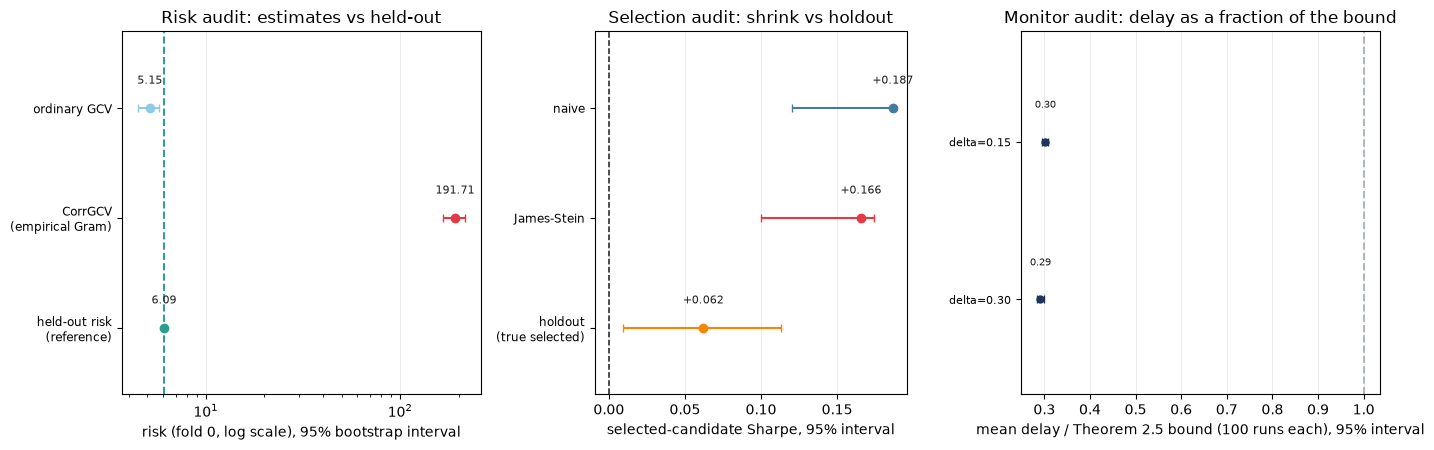

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.6), gridspec_kw={"width_ratios": [1.15, 1.0, 1.15]})
risk_rows = [("ordinary GCV", RISK_PANEL["ordinary_gcv"], RISK_PANEL["ordinary_gcv_ci"], PALETTE["gcv"]),
             ("CorrGCV\n(empirical Gram)", RISK_PANEL["corrgcv"], RISK_PANEL["corrgcv_ci"], PALETTE["corrgcv"]),
             ("held-out risk\n(reference)", RISK_PANEL["heldout"], RISK_PANEL["heldout_ci"], PALETTE["holdout"])]
ys0 = np.arange(len(risk_rows))[::-1]
for yi, (name, v, (lo, hi), col) in zip(ys0, risk_rows):
    axes[0].errorbar([v], [yi], xerr=[[max(v - lo, 1e-12)], [max(hi - v, 1e-12)]], fmt="o",
                     color=col, markersize=6, elinewidth=1.5, capsize=3)
    axes[0].annotate(f"{v:.2f}", (v, yi + 0.2), ha="center", va="bottom", color=PALETTE["ink"], fontsize=8)
axes[0].axvline(RISK_PANEL["heldout"], color=PALETTE["holdout"], lw=1.4, ls="--")
axes[0].set_xscale("log")
axes[0].set_yticks(ys0)
axes[0].set_yticklabels([r[0] for r in risk_rows], fontsize=8.5)
axes[0].set_ylim(-0.6, len(risk_rows) - 0.3)
axes[0].set_xlabel("risk (fold 0, log scale), 95% bootstrap interval")
axes[0].set_title("Risk audit: estimates vs held-out")
sel_rows = [("naive", SELECTION_PANEL["naive"], SELECTION_CI["naive"], PALETTE["observed"]),
            ("James-Stein", SELECTION_PANEL["js"], SELECTION_CI["js"], PALETTE["corrgcv"]),
            ("holdout\n(true selected)", SELECTION_PANEL["holdout"], SELECTION_CI["holdout"], PALETTE["true"])]
ys1 = np.arange(len(sel_rows))[::-1]
for yi, (name, v, (lo, hi), col) in zip(ys1, sel_rows):
    axes[1].errorbar([v], [yi], xerr=[[v - lo], [hi - v]], fmt="o", color=col,
                     markersize=6, elinewidth=1.5, capsize=3)
    axes[1].annotate(f"{v:+.3f}", (v, yi + 0.2), ha="center", va="bottom", color=PALETTE["ink"], fontsize=8)
axes[1].axvline(0.0, color=PALETTE["ink"], lw=1.1, ls="--")
axes[1].set_yticks(ys1)
axes[1].set_yticklabels([r[0] for r in sel_rows], fontsize=8.5)
axes[1].set_ylim(-0.6, len(sel_rows) - 0.3)
axes[1].set_xlabel("selected-candidate Sharpe, 95% interval")
axes[1].set_title("Selection audit: shrink vs holdout")
mon_rows = sorted(MONITOR_PANEL, key=lambda p: p["delta"])
ys2 = np.arange(len(mon_rows))[::-1]
for yi, p in zip(ys2, mon_rows):
    axes[2].errorbar([p["ratio"]], [yi], xerr=[[p["ratio"] - p["ratio_lo"]], [p["ratio_hi"] - p["ratio"]]],
                     fmt="o", color=PALETTE["stream"], markersize=5, elinewidth=1.4, capsize=3)
    axes[2].annotate(f"{p['ratio']:.2f}", (p["ratio"], yi + 0.2), ha="center", va="bottom",
                     color=PALETTE["ink"], fontsize=7.5)
axes[2].axvline(1.0, color=PALETTE["bound"], lw=1.4, ls="--")
axes[2].set_yticks(ys2)
axes[2].set_yticklabels([f"delta={p['delta']:.2f}" for p in mon_rows], fontsize=8)
axes[2].set_ylim(-0.6, len(mon_rows) - 0.3)
axes[2].set_xlabel("mean delay / Theorem 2.5 bound (100 runs each), 95% interval")
axes[2].set_title("Monitor audit: delay as a fraction of the bound")
for ax in axes:
    ax.grid(color=PALETTE["grid"], lw=0.5, alpha=0.7, axis="x")
plt.tight_layout()
plt.show()

## Limitations — what the three sources do not settle

This notebook is a synthetic-data research study — not production trading code, and not evidence of live performance. Every gap below survived an
explicit attempt.

- A confidence sequence valid under serial dependence and heavy tails is not established for the monitored
  stream: its lag-1 autocorrelation is ≈ 0.9965 (the rolling hit rate is close to a random walk), so the
  independence-based forward-CS guarantee does not apply to the detector's output; tried: measuring the lag-1
  autocorrelation of the stored stream, re-running the same repeated-FCS detector on it, and reporting the alarm
  as a diagnostic with `dependence validity not established` instead of a certified false-alarm rate
  (leakage-proof-ts-q10.json).
- The exact CorrGCV value on an empirical Gram is a derived-here diagnostic, not the paper's matched-correlation
  guarantee: the coupled `(kappa, kappa_tilde)` system is solved to ~1e-16 on the empirical feature and sample
  spectra, but recovering the sample-side S-transform from the empirical Gram requires the deconvolution the paper calls
  intractable without a parametric model of the feature covariance; tried: solving the renormalised system,
  printing both identity residuals, and comparing the result against the held-out fold risk, where the plug-in
  value is off by more than an order of magnitude (leakage-proof-ts-q4.json).
- Purge and embargo widths, and a cost/turnover model, on real data are untested: purge = label horizon + 2 and
  embargo = 2 are derived here and validated only against this synthetic generator's 6-bar label window; tried:
  re-checking fold coverage under those widths from part-1's stored split indices, but no real label horizon
  exists to calibrate against and no source states a transaction-cost or slippage model, so no Sharpe here is a
  tradable return (leakage-proof-ts-q12.json).
- Treating seeds, architectures and ridge penalties as Pav "strategies" is derived here: the eight declared
  candidates include two penalty variants and several feature-set families, and the exchangeable-normal model Pav
  assumes does not cover a seed/architecture search manifold; tried: declaring the candidate set before scoring,
  applying the James-Stein shrink with the applicability caveat, and reporting the naive estimate beside it, but
  no correction for correlated candidates is implemented (leakage-proof-ts-q7.json).
- The selection family is reduced to one estimator: only the James-Stein-style shrink is computed for the
  declared candidate set, while Pav's expected-maximum, SURE, GMLEB and polyhedral estimators are not; tried:
  comparing naive, shrink and holdout on the same declared candidates, which bounds the effect on this set but
  does not test the wider family (leakage-proof-ts-q6.json).
- Detector restart, multi-change and gradual-drift behaviour are unsettled: the monitor runs once, records at
  most one alarm and never restarts, and the source analyses a single changepoint with a bounded pre-change
  regime; tried: running the detector once with no restart and storing the step-by-step trace, but a
  restart/refractory policy and cumulative multi-alarm error control have no implementation here
  (leakage-proof-ts-q10.json).
- The stationary Toeplitz `K_hat` route does not rescue CorrGCV here, and the estimate is a derived-here
  diagnostic, not the paper's matched-correlation guarantee: over the 12-point lambda sweep the mean relative
  error between the plotted fold-mean curves is 78.4 for CorrGCV on the empirical Gram, 50.2 for CorrGCV on the
  Toeplitz `K_hat` (1.6x closer on average, 3.6x closer at the smallest lambda) and 0.04 for ordinary GCV -- so
  the q4 O(T)-parameter estimate moves the plug-in value in the right direction without closing the gap, exactly
  because the sample-side S-transform still has to be recovered from the data; tried: replacing the sample-Gram
  spectrum with the Toeplitz spectrum of the training rows' lag-autocorrelation inside the same renormalised
  `(kappa, kappa_tilde)` solve, at every lambda on every clean fold, and printing the paired relative errors
  (leakage-proof-ts-q4.json).
- The Eq. (44) band is a stationary idealisation of a series this generator makes non-stationary: the Toeplitz
  `K_hat` is estimated on the trailing 700 rows of each clean fold while the planted regime changes and GARCH
  volatility clustering sit inside that window, so the stored factor is a derived-here reading of the theorem,
  not a test of it; tried: computing the factor and its bracket on every clean fold and reporting them beside
  NB2's measured ratio, which is where the theorem's own band and this generator's behaviour can be compared
  (leakage-proof-ts-q4.json).